# Epithelial Cell BBKNN Integration Pipeline - Linear Execution Version

Complete BBKNN batch correction workflow with:
1. Complete BBKNN batch correction workflow with post-hoc parameter validation
2. Force retention of specified markers (avoid removal in HVG/filtering)
3. Differential analysis/plotting defaults to reading from .raw full gene matrix (use_raw=True)
4. Multi-resolution Leiden clustering; UMAP uses BBKNN-constructed neighbor graph
5. Detailed and reproducible visualization and reporting

Author: Clinical-Bioinformatics Team  
Version: v1.3 - Linear Execution

## Import Libraries

In [2]:
import sys
import os
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
from scipy.sparse import issparse, csr_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import time
from tqdm import tqdm
import pickle
import scanpy as sc
from bbknn import bbknn as bbknn_func
from datetime import datetime

warnings.filterwarnings('ignore')

print(f"scanpy version: {sc.__version__}")
print("bbknn: installed")

scanpy version: 1.9.8
bbknn: installed


/home/h2048/miniconda3/envs/bbknn_env/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configuration Parameters

In [3]:
# ---------- Input/Output ----------
INPUT_H5AD_PATH = "/home/h2048/data/py/1128/bbknn_celltype_analysis/Epithelial/adata_Epithelial_bbknn.h5ad"
OUTPUT_DIR = "/home/h2048/data/py/1128/bbknn_celltype_analysis/Epithelial/output_optimized"
OVERWRITE_EXISTING = True

# ---------- BBKNN Integration Parameters ----------
BATCH_KEY = "dataset"
BBKNN_NEIGHBORS_WITHIN_BATCH = 3
BBKNN_N_PCS = 50

# ---------- High Variable Genes (HVG) ----------
USE_HVG = True
N_TOP_GENES = 2000
HVG_FLAVOR = "seurat_v3"

# ---------- Gene Filtering ----------
MIN_CELLS_PER_GENE = 3

# ---------- Raw Counts Source ----------
RAW_COUNTS_SOURCE = "auto"

# ---------- Normalization ----------
NORMALIZE_TOTAL = True
TARGET_SUM = 1e4
LOG_TRANSFORM = True
SCALE_DATA = True
MAX_VALUE = 10

# ---------- PCA ----------
N_PCS = 50

# ---------- Dimensionality Reduction/Visualization ----------
RUN_UMAP = True
UMAP_MIN_DIST = 0.5

# ---------- Clustering ----------
RUN_CLUSTERING = True
LEIDEN_RESOLUTIONS = [1.2, 1.6, 2.0, 2.4, 2.8]
DEFAULT_RESOLUTION = 2.0

# ---------- Marker Gene Analysis ----------
RUN_FIND_MARKERS = True
MARKER_MIN_PCT = 0.25
MARKER_LOGFC_THRESHOLD = 0.25
TOP_N_MARKERS = 10

# ---------- Performance/Caching ----------
USE_CACHE = True
CHUNK_SIZE = 100

# ---------- Visualization ----------
GENERATE_DOTPLOT = True
GENERATE_HEATMAP = True
GENERATE_FACET_PLOTS = True
DPI = 300
FIGURE_FORMAT = "png"

VERBOSE = True

print("Configuration loaded successfully")

Configuration loaded successfully


In [4]:
# ---------- Epithelial Cell Marker Genes ----------
MARKER_EPITHELIAL = [
    # Basal
    'TP63','KRT5','KRT14',
    # Secretory
    'SCGB1A1','SERPINB3','SCGB3A2','SCGB3A1','TCN1','ASRGL1',
    # Ciliated
    'FOXJ1','RSPH1','PIFO','BEST4','C20orf85','C9orf24',
    # Differentiation
    'KRT19','NOTCH3','KRT16','KRT23',
    # Goblet
    'MUC5AC','SPDEF','LYPD2','ITLN1',
    # Neuroendocrine
    'ASCL1','GRP','KRT8',
    # Tuft / Ionocytes
    'POU2F3','ASCL2','CFTR','FOXI1','ASCL3','BSND','IGF1','CLCNKB','PDE1C',
    # AT1
    'AGER','RTKN2','CLIC5','SPOCK2','TIMP3',
    # AT2
    'SFTPC','LAMP3','MFSD2A','C8orf4','C11orf96','SFTPB','SFTA2',
    # Mesenchymal
    'VIM','SOX9','MYH11','ACTA2','MYLK',
    # Secretory/Immune
    'DMBT1','RNASE1','MUC5B','LYZ','LTF','PIP','CCL28',
    # Ciliogenesis
    'DEUP1','FOXN4','CDC20B','CCNO',
    # Proliferation
    'MKI67','TOP2A','TK1','CENPW'
]

# Key markers for cell typing/visualization
KEY_MARKERS = {
    'Basal': ['TP63','KRT5'],
    'Secretory': ['SCGB1A1','SCGB3A2'],
    'Ciliated': ['FOXJ1','RSPH1'],
    'Goblet': ['MUC5AC','SPDEF'],
    'Tuft': ['POU2F3','ASCL2'],
    'Ionocyte': ['FOXI1','CFTR'],
    'AT1': ['AGER','RTKN2'],
    'AT2': ['SFTPC','SFTPB'],
    'Proliferating': ['MKI67','TOP2A']
}

# Force include markers
FORCE_INCLUDE_MARKERS = sorted({
    *MARKER_EPITHELIAL,
    *[g for genes in KEY_MARKERS.values() for g in genes],
})

print(f"Total markers defined: {len(MARKER_EPITHELIAL)}")
print(f"Force include markers: {len(FORCE_INCLUDE_MARKERS)}")

Total markers defined: 67
Force include markers: 67


## Initialize Output Directory and Timing

In [5]:
print("\n" + "="*70)
print("Epithelial Cell BBKNN Integration Pipeline (Optimized v1.3)")
print("="*70)

start_time = time.time()

output_dir = Path(OUTPUT_DIR)
output_dir.mkdir(parents=True, exist_ok=True)
print(f"\nOutput directory: {output_dir}")


Epithelial Cell BBKNN Integration Pipeline (Optimized v1.3)

Output directory: /home/h2048/data/py/1128/bbknn_celltype_analysis/Epithelial/output_optimized


## Step 1: Load Data

In [6]:
print("\n" + "="*70)
print("Step 1: Load Data")
print("="*70)

print(f"\nReading file: {INPUT_H5AD_PATH}")
if not Path(INPUT_H5AD_PATH).exists():
    raise FileNotFoundError(f"File not found: {INPUT_H5AD_PATH}")

adata = sc.read_h5ad(INPUT_H5AD_PATH)
print(f"Data loaded successfully")
print(f"   Cells: {adata.n_obs:,}")
print(f"   Genes: {adata.n_vars:,}")


Step 1: Load Data

Reading file: /home/h2048/data/py/1128/bbknn_celltype_analysis/Epithelial/adata_Epithelial_bbknn.h5ad
Data loaded successfully
   Cells: 278,930
   Genes: 53,973


In [7]:
print(f"\nAvailable metadata columns:")
for col in adata.obs.columns:
    n_unique = adata.obs[col].nunique()
    print(f"   - {col}: {n_unique} unique values")

if BATCH_KEY not in adata.obs.columns:
    raise ValueError(f"Batch column '{BATCH_KEY}' not found in adata.obs")


Available metadata columns:
   - orig.ident: 28 unique values
   - nCount_RNA: 34155 unique values
   - nFeature_RNA: 5785 unique values
   - plateID: 29 unique values
   - status: 2 unique values
   - donorID: 7 unique values
   - cDate: 7 unique values
   - age: 7 unique values
   - sex: 5 unique values
   - cellType: 10 unique values
   - percent.mt: 226850 unique values
   - percent.ribo: 153343 unique values
   - tissue: 4 unique values
   - tissue_sampling_method: 5 unique values
   - dataset: 22 unique values
   - sample: 161 unique values
   - percent.rb: 66569 unique values
   - decontX_contamination: 278930 unique values
   - decontX_clusters: 236 unique values
   - nCount_decontXcounts: 25788 unique values
   - nFeature_decontXcounts: 5773 unique values
   - donor_id: 96 unique values
   - Group: 3 unique values
   - Ethnicity_inferred: 6 unique values
   - Smoker: 3 unique values
   - COVID_status: 2 unique values
   - First_symptoms_collection_interval: 1 unique values
  

In [8]:
print(f"\nBatch distribution (key: {BATCH_KEY}):")
batch_counts = adata.obs[BATCH_KEY].value_counts().sort_index()
for batch, count in batch_counts.items():
    pct = count / adata.n_obs * 100
    print(f"   {batch}: {count:,} cells ({pct:.1f}%)")


Batch distribution (key: dataset):
   Banovich_Kropski_2020: 9,139 cells (3.3%)
   Barbry_Leroy_2020: 25,821 cells (9.3%)
   Guanrui_Liao_2025: 3,998 cells (1.4%)
   Jain_Misharin_2021_10Xv1: 8,596 cells (3.1%)
   Jain_Misharin_2021_10Xv2: 19,972 cells (7.2%)
   Jennifer_P_Wang_2021: 1,166 cells (0.4%)
   Ji_Hoon_Ahn_2021: 15,350 cells (5.5%)
   Kerstin_B_Meyer_2021: 62,054 cells (22.2%)
   Lafyatis_Rojas_2019_10Xv1: 166 cells (0.1%)
   Lafyatis_Rojas_2019_10Xv2: 679 cells (0.2%)
   Maya_E_Kotas_2022: 45,673 cells (16.4%)
   Meyer_2019: 1,891 cells (0.7%)
   Misharin_2021: 9,040 cells (3.2%)
   Misharin_Budinger_2018: 9,929 cells (3.6%)
   Nawijn_2021: 25,651 cells (9.2%)
   Ordovas_Montanes_2018: 5,425 cells (1.9%)
   Seibold_2020_10Xv2: 3,910 cells (1.4%)
   Seibold_2020_10Xv3: 3,710 cells (1.3%)
   Tine_Wils_2024: 5,559 cells (2.0%)
   Waradon_Sungnak_2020: 6,338 cells (2.3%)
   Weiqing_Wang_2022: 12,507 cells (4.5%)
   Xinyu_Xie_2024: 2,356 cells (0.8%)


## Step 2: Check Marker Genes

In [9]:
print("\n" + "="*70)
print("Step 2: Check Marker Genes")
print("="*70)

raw_names = set(adata.raw.var_names) if adata.raw is not None else set()
var_names = set(adata.var_names)

def present(g):
    return (g in var_names) or (g in raw_names)

available_markers = [g for g in MARKER_EPITHELIAL if present(g)]
missing_markers   = [g for g in MARKER_EPITHELIAL if not present(g)]

print(f"\nMarker gene availability:")
print(f"   Total: {len(MARKER_EPITHELIAL)}")
print(f"   Available: {len(available_markers)} ({len(available_markers)/len(MARKER_EPITHELIAL)*100:.1f}%)")
print(f"   Missing: {len(missing_markers)} ({len(missing_markers)/len(MARKER_EPITHELIAL)*100:.1f}%)")

if missing_markers:
    print(f"\n   Missing genes (sample): {', '.join(missing_markers[:10])}")
    if len(missing_markers) > 10:
        print(f"   ... and {len(missing_markers)-10} more")

print(f"\nKey cell type markers:")
for celltype, genes in KEY_MARKERS.items():
    available = [g for g in genes if present(g)]
    print(f"   {celltype}: {len(available)}/{len(genes)} available")


Step 2: Check Marker Genes

Marker gene availability:
   Total: 67
   Available: 67 (100.0%)
   Missing: 0 (0.0%)

Key cell type markers:
   Basal: 2/2 available
   Secretory: 2/2 available
   Ciliated: 2/2 available
   Goblet: 2/2 available
   Tuft: 2/2 available
   Ionocyte: 2/2 available
   AT1: 2/2 available
   AT2: 2/2 available
   Proliferating: 2/2 available


## Step 3: Preprocessing - Save Raw Counts to Layers

In [10]:
print("\n" + "="*70)
print(f"Step 3: Select HVGs (n={N_TOP_GENES}) and set layers")
print("-"*70)

# 1) Ensure raw counts in layers['counts']
if 'counts' in adata.layers:
    counts = adata.layers['counts']
    print("   Using existing layers['counts'] as raw counts")
elif getattr(adata, "raw", None) is not None:
    counts = adata.raw.X
    print("   Extracting raw counts from .raw -> layers['counts']")
else:
    counts = adata.X
    print("   No .raw detected, using current X as raw counts -> layers['counts']")

if not issparse(counts):
    counts = csr_matrix(counts)
adata.layers['counts'] = counts

print(f"   Raw counts saved to layers['counts']")


Step 3: Select HVGs (n=2000) and set layers
----------------------------------------------------------------------
   Using existing layers['counts'] as raw counts
   Raw counts saved to layers['counts']


## Step 3.1: HVG Selection

In [11]:
# 2) HVG selection (with robust fallback)
adata.X = adata.layers['counts'].copy()

try:
    sc.pp.highly_variable_genes(
        adata,
        n_top_genes=N_TOP_GENES,
        flavor="seurat_v3",
        batch_key=BATCH_KEY
    )
    print(f"   HVG(seurat_v3, batch_key={BATCH_KEY}) successful")
except Exception as e:
    print(f"   ⚠️  HVG(seurat_v3, batch_key={BATCH_KEY}) failed: {repr(e)}")
    print("      → Fallback to seurat_v3 without batch_key")
    sc.pp.highly_variable_genes(
        adata,
        n_top_genes=N_TOP_GENES,
        flavor="seurat_v3",
        batch_key=None
    )

hv_mask = adata.var['highly_variable'].to_numpy(dtype=bool)

# Force retain markers
force_mask = adata.var_names.isin(FORCE_INCLUDE_MARKERS)

keep_mask = hv_mask | force_mask
n_force = int(force_mask.sum())
print(f"   Selected HVGs: {int(hv_mask.sum())}; Force retained: {n_force}; Total: {int(keep_mask.sum())}")

   ⚠️  HVG(seurat_v3, batch_key=dataset) failed: ValueError(b'reciprocal condition number  2.6618e-16\n')
      → Fallback to seurat_v3 without batch_key
   Selected HVGs: 2000; Force retained: 67; Total: 2017


## Step 3.2: Normalize Full Matrix

In [12]:
# 3) Normalize on full matrix to get adata_full (X=log1p)
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
adata.layers['log1p'] = adata.X.copy()

print(f"   Full matrix normalized and log-transformed")
print(f"   layers['log1p'] created")

   Full matrix normalized and log-transformed
   layers['log1p'] created


## Step 3.3: Create HVG Subset

In [13]:
# 4) Create HVG subset object
adata_full = adata.copy()
adata_hvg = adata[:, keep_mask].copy()
adata_hvg.layers['counts'] = adata.layers['counts'][:, keep_mask].copy()

print(f"   Created HVG subset with {adata_hvg.n_vars} genes")

   Created HVG subset with 2017 genes


In [14]:
# Make HVG subset X = log1p of subset counts
adata_hvg.X = adata_hvg.layers['counts'].copy()
sc.pp.normalize_total(adata_hvg, target_sum=1e4)
sc.pp.log1p(adata_hvg)
adata_hvg.layers['log1p'] = adata_hvg.X.copy()

print(f"   HVG subset normalized and log-transformed")

   HVG subset normalized and log-transformed


In [15]:
# 5) Record basic metadata
adata_hvg.uns['hvg_n_top_genes'] = int(N_TOP_GENES)
adata_hvg.uns['force_include_markers'] = np.array(FORCE_INCLUDE_MARKERS, dtype=str)
adata_hvg.uns['keep_mask_sum'] = int(keep_mask.sum())

# 6) Set full gene data as HVG subset's .raw
adata_hvg.raw = adata_full
print(f"   Set adata_hvg.raw = adata_full (contains {adata_full.n_vars} genes)")
print("   ✓ Complete: raw counts in layers['counts'], log1p in layers['log1p']")
print("="*70)

   Set adata_hvg.raw = adata_full (contains 53973 genes)
   ✓ Complete: raw counts in layers['counts'], log1p in layers['log1p']


## Step 3.5: PCA

In [16]:
print(f"\nRunning PCA (n_comps={N_PCS})...")
sc.tl.pca(adata_hvg, n_comps=N_PCS, svd_solver='arpack')

var_ratio = adata_hvg.uns['pca']['variance_ratio']
cumsum_var = np.cumsum(var_ratio)
if len(cumsum_var) >= 50:
    print(f"   PC1-10 explained variance: {cumsum_var[9]:.2%}")
    print(f"   PC1-20 explained variance: {cumsum_var[19]:.2%}")
    print(f"   PC1-50 explained variance: {cumsum_var[49]:.2%}")


Running PCA (n_comps=50)...
   PC1-10 explained variance: 36.81%
   PC1-20 explained variance: 43.31%
   PC1-50 explained variance: 51.68%


## Step 4: BBKNN Batch Integration

In [17]:
print("\n" + "="*70)
print("Step 4: BBKNN Batch Integration")
print("="*70)

print("\nBBKNN parameters:")
print(f"   batch_key: {BATCH_KEY}")
print(f"   neighbors_within_batch: {BBKNN_NEIGHBORS_WITHIN_BATCH}")
print(f"   n_pcs: {BBKNN_N_PCS}")

print("\nRunning BBKNN...")
bbknn_start = time.time()
bbknn_func(
    adata_hvg,
    batch_key=BATCH_KEY,
    neighbors_within_batch=BBKNN_NEIGHBORS_WITHIN_BATCH,
    n_pcs=BBKNN_N_PCS,
    copy=False
)
bbknn_time = time.time() - bbknn_start
print(f"\n   BBKNN complete, time elapsed: {bbknn_time:.1f} seconds")


Step 4: BBKNN Batch Integration

BBKNN parameters:
   batch_key: dataset
   neighbors_within_batch: 3
   n_pcs: 50

Running BBKNN...

   BBKNN complete, time elapsed: 370.2 seconds


In [18]:
# BBKNN sanity check
try:
    n_batches = adata_hvg.obs[BATCH_KEY].nunique()
    expected = BBKNN_NEIGHBORS_WITHIN_BATCH * n_batches
    neigh = adata_hvg.uns.get('neighbors', {}).get('params', {})
    actual = neigh.get('n_neighbors', None)
    print(
        f"   BBKNN check → n_batches={n_batches}, "
        f"neighbors_within_batch={BBKNN_NEIGHBORS_WITHIN_BATCH} → "
        f"expected total neighbors≈{expected}, actual {actual}"
    )
except Exception as e:
    print(f"   ⚠️ BBKNN post-hoc validation failed: {e}")

   BBKNN check → n_batches=22, neighbors_within_batch=3 → expected total neighbors≈66, actual 66


## Step 5: UMAP and Multi-resolution Clustering

In [21]:
print("\n" + "="*70)
print("Step 5: UMAP and Multi-resolution Clustering")
print("="*70)


Step 5: UMAP and Multi-resolution Clustering


In [22]:
if RUN_UMAP:
    print(f"\nRunning UMAP (min_dist={UMAP_MIN_DIST}, using BBKNN neighbor graph)...")
    sc.tl.umap(adata_hvg, min_dist=UMAP_MIN_DIST)
    print("   UMAP complete")


Running UMAP (min_dist=0.5, using BBKNN neighbor graph)...
   UMAP complete


In [23]:
if RUN_CLUSTERING:
    print(f"\nRunning multi-resolution Leiden clustering...")
    print(f"   Resolution list: {LEIDEN_RESOLUTIONS}")
    for res in LEIDEN_RESOLUTIONS:
        cluster_key = f'leiden_bbknn_res{res}'
        try:
            sc.tl.leiden(adata_hvg, resolution=res, key_added=cluster_key, flavor='igraph',
                         n_iterations=2, directed=False)
        except TypeError:
            sc.tl.leiden(adata_hvg, resolution=res, key_added=cluster_key, n_iterations=2)
        n_clusters = adata_hvg.obs[cluster_key].nunique()
        print(f"   Resolution {res}: {n_clusters} clusters")
    
    default_key = f'leiden_bbknn_res{DEFAULT_RESOLUTION}'
    adata_hvg.obs['leiden_bbknn'] = adata_hvg.obs[default_key]
    print(f"\n   Default clustering: {default_key}")


Running multi-resolution Leiden clustering...
   Resolution list: [1.2, 1.6, 2.0, 2.4, 2.8]
   Resolution 1.2: 20 clusters
   Resolution 1.6: 23 clusters
   Resolution 2.0: 30 clusters
   Resolution 2.4: 33 clusters
   Resolution 2.8: 34 clusters

   Default clustering: leiden_bbknn_res2.0


## Step 6: Compute Cluster Differential Genes

In [24]:
if RUN_FIND_MARKERS:
    print("\n" + "="*70)
    print("Step 6: Compute Cluster Differential Genes (Optimized)")
    print("="*70)
    
    cache_file = "epithelial_markers_cache.pkl"
    cache_path = output_dir / f".cache_{cache_file}"
    
    if USE_CACHE and cache_path.exists():
        print("\n   Loading from cache...")
        with open(cache_path, 'rb') as f:
            all_markers = pickle.load(f)
        print(f"   Total markers: {len(all_markers)}")
    else:
        markers_file = output_dir / "cluster_markers.csv"
        
        print(f"\nRunning differential analysis (Wilcoxon)...")
        print(f"   min_pct: {MARKER_MIN_PCT}")
        print(f"   logfc_threshold: {MARKER_LOGFC_THRESHOLD}")
        
        print("\n   Computing differentials...")
        sc.tl.rank_genes_groups(
            adata_hvg,
            groupby='leiden_bbknn',
            method='wilcoxon',
            key_added='rank_genes_groups',
            use_raw=True,
            layer=None
        )
        print("   ✓ Differential analysis complete")


Step 6: Compute Cluster Differential Genes (Optimized)

   Loading from cache...
   Total markers: 0


In [25]:
if RUN_FIND_MARKERS and not (USE_CACHE and cache_path.exists()):
    print("\n   Extracting and filtering differential results...")
    
    # Helper function for computing pct expressed
    def compute_pct_expressed_vectorized(adata, cluster_key, cluster, genes):
        cluster_mask = (adata.obs[cluster_key] == cluster).values
        n_in = int(cluster_mask.sum()); n_out = int((~cluster_mask).sum())
        if n_in == 0 or n_out == 0 or len(genes) == 0:
            return [], []

        genes_in_var = [g for g in genes if g in adata.var_names]
        rem = [g for g in genes if g not in adata.var_names]
        X_in = X_out = None

        if genes_in_var:
            Xin = adata[cluster_mask, genes_in_var].X
            Xout = adata[~cluster_mask, genes_in_var].X
            Xin = Xin.toarray() if hasattr(Xin, 'toarray') else np.asarray(Xin)
            Xout = Xout.toarray() if hasattr(Xout, 'toarray') else np.asarray(Xout)
            X_in, X_out = Xin, Xout

        if rem and (adata.raw is not None):
            raw_names = np.array(adata.raw.var_names)
            raw_map = {g:i for i,g in enumerate(raw_names)}
            rem_exist = [g for g in rem if g in raw_map]
            if rem_exist:
                ridx = [raw_map[g] for g in rem_exist]
                R = adata.raw.X
                Rin = R[cluster_mask][:, ridx]
                Rout = R[~cluster_mask][:, ridx]
                Rin = Rin.toarray() if hasattr(Rin, 'toarray') else np.asarray(Rin)
                Rout = Rout.toarray() if hasattr(Rout, 'toarray') else np.asarray(Rout)
                if X_in is None:
                    X_in, X_out = Rin, Rout
                    genes_in_var = rem_exist
                else:
                    X_in = np.concatenate([X_in, Rin], axis=1)
                    X_out = np.concatenate([X_out, Rout], axis=1)
                    genes_in_var = genes_in_var + rem_exist

        if X_in is None:
            return [], []
        pct_in  = (X_in  > 0).sum(axis=0) / n_in
        pct_out = (X_out > 0).sum(axis=0) / n_out
        return pct_in.tolist(), pct_out.tolist()
    
    clusters = adata_hvg.obs['leiden_bbknn'].unique()
    markers_list = []

    for cluster in tqdm(clusters, desc="Processing clusters"):
        df = sc.get.rank_genes_groups_df(adata_hvg, group=cluster)
        df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=["logfoldchanges","pvals_adj"])
        df = df[(df["logfoldchanges"] > MARKER_LOGFC_THRESHOLD) & (df["pvals_adj"] < 0.05)].copy()
        if df.empty:
            continue

        genes = df["names"].tolist()
        pct_in, pct_out = compute_pct_expressed_vectorized(adata_hvg, 'leiden_bbknn', cluster, genes)
        if len(pct_in) != len(genes):
            n = len(genes)
            pct_in  = (pct_in  + [np.nan]*(n-len(pct_in)))[:n]
            pct_out = (pct_out + [np.nan]*(n-len(pct_out)))[:n]

        df["cluster"] = cluster
        df["pct_in_cluster"] = pct_in
        df["pct_out_cluster"] = pct_out
        df = df[df["pct_in_cluster"] > MARKER_MIN_PCT]
        if df.empty:
            continue

        if TOP_N_MARKERS is not None and TOP_N_MARKERS > 0:
            df = df.sort_values("pvals_adj", ascending=True).head(TOP_N_MARKERS)
        markers_list.append(df)

    if len(markers_list) == 0:
        print("\n   ⚠️ No differential genes meet current thresholds, returning empty results.")
        empty_cols = ["names","scores","logfoldchanges","pvals","pvals_adj","cluster","pct_in_cluster","pct_out_cluster"]
        all_markers = pd.DataFrame(columns=empty_cols)
    else:
        all_markers = pd.concat(markers_list, ignore_index=True)
        print(f"\n   ✓ Total {len(all_markers)} markers obtained, covering {len(clusters)} clusters")
    
    # Save to cache and CSV
    if USE_CACHE:
        with open(cache_path, 'wb') as f:
            pickle.dump(all_markers, f)
        print(f"   Checkpoint saved: {cache_path}")
    
    all_markers.to_csv(markers_file, index=False)
    print(f"   ✓ Saved: {markers_file}")

## Step 7: Generate Visualizations

In [26]:
if RUN_UMAP:
    print("\n" + "="*70)
    print("Step 7: Generate Visualizations")
    print("="*70)

    fig_dir = output_dir / "figures"
    fig_dir.mkdir(exist_ok=True)
    sc.settings.figdir = fig_dir
    
    print(f"\nFigures will be saved to: {fig_dir}")


Step 7: Generate Visualizations

Figures will be saved to: /home/h2048/data/py/1128/bbknn_celltype_analysis/Epithelial/output_optimized/figures


In [27]:
if RUN_UMAP:
    # 1) Overview plot
    print("\n   Generating integration quality overview...")
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    sc.pl.umap(adata_hvg, color=BATCH_KEY, ax=axes[0], show=False, title='Batch')
    sc.pl.umap(adata_hvg, color='leiden_bbknn', ax=axes[1], show=False,
               title='Clusters', legend_loc='on data', legend_fontsize=8)
    if 'cell_type' in adata_hvg.obs.columns:
        sc.pl.umap(adata_hvg, color='cell_type', ax=axes[2], show=False, title='Cell Type')
    else:
        axes[2].axis('off')
    plt.tight_layout()
    plt.savefig(fig_dir / f'umap_overview.{FIGURE_FORMAT}', dpi=DPI, bbox_inches='tight')
    plt.close()
    print(f"   ✓ Overview UMAP saved")


   Generating integration quality overview...
   ✓ Overview UMAP saved


In [28]:
if RUN_UMAP and RUN_CLUSTERING and len(LEIDEN_RESOLUTIONS) > 1:
    # 2) Multi-resolution clustering
    print("\n   Generating multi-resolution clustering plots...")
    n_res = len(LEIDEN_RESOLUTIONS)
    n_cols = 3
    n_rows = (n_res + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 6*n_rows))
    axes = axes.flatten() if n_res > 1 else [axes]
    for i, res in enumerate(LEIDEN_RESOLUTIONS):
        cluster_key = f'leiden_bbknn_res{res}'
        sc.pl.umap(
            adata_hvg, color=cluster_key, ax=axes[i], show=False,
            title=f'Resolution {res}', legend_loc='on data', legend_fontsize=8
        )
    for i in range(n_res, len(axes)):
        axes[i].axis('off')
    plt.tight_layout()
    plt.savefig(fig_dir / f'umap_resolutions.{FIGURE_FORMAT}', dpi=DPI, bbox_inches='tight')
    plt.close()
    print(f"   ✓ Multi-resolution UMAP saved")


   Generating multi-resolution clustering plots...
   ✓ Multi-resolution UMAP saved



   Generating marker expression UMAPs...


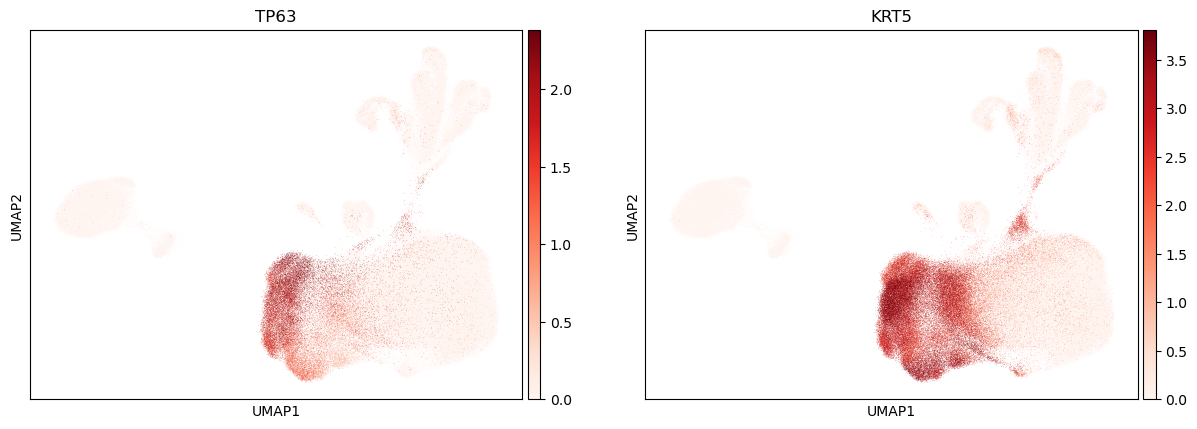

   ✓ Basal markers UMAP saved


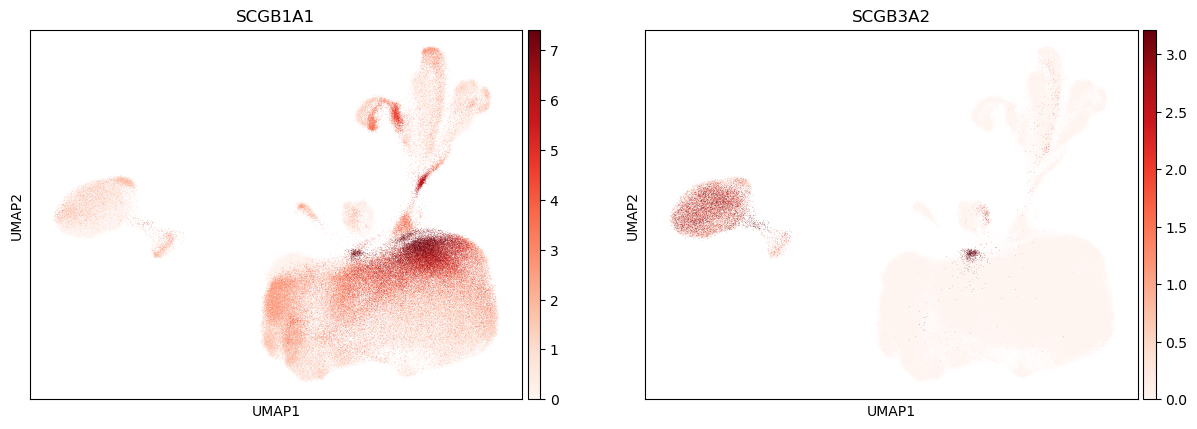

   ✓ Secretory markers UMAP saved


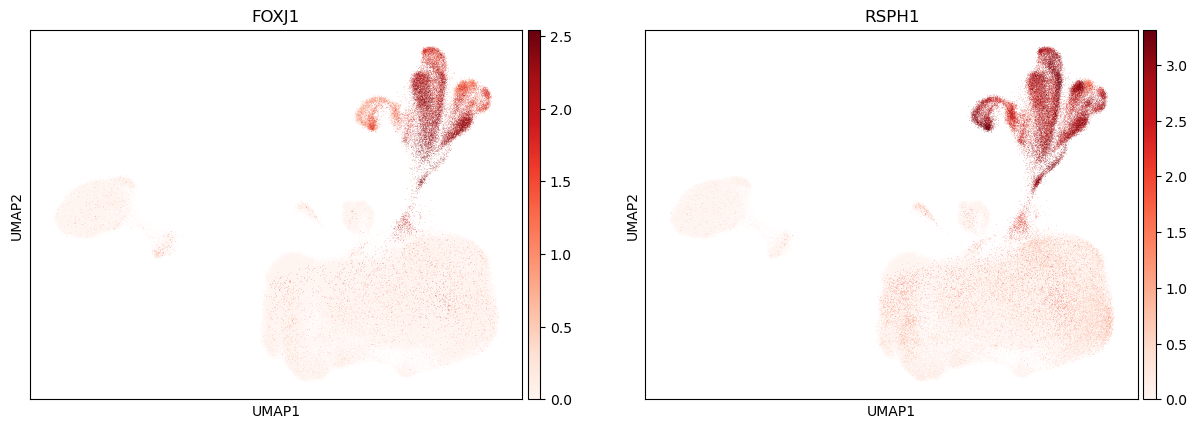

   ✓ Ciliated markers UMAP saved


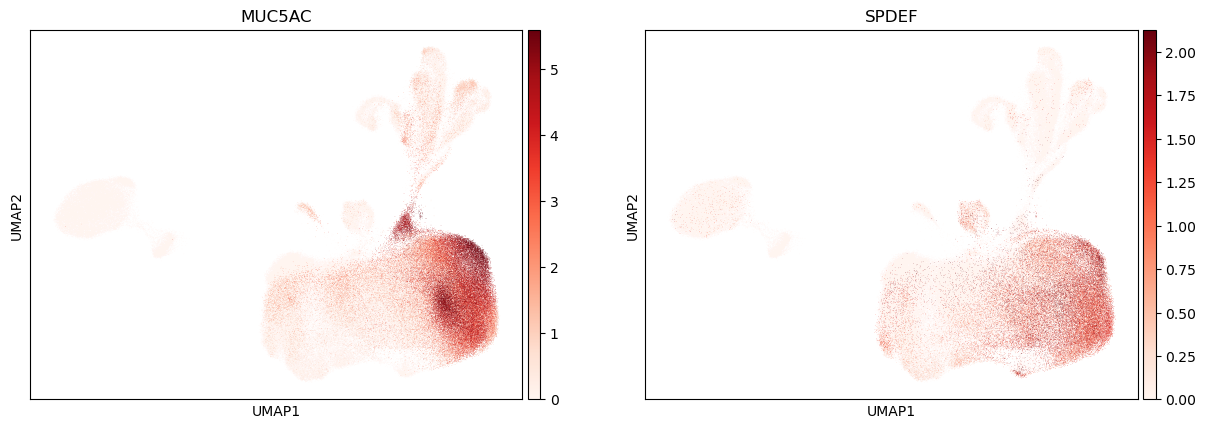

   ✓ Goblet markers UMAP saved


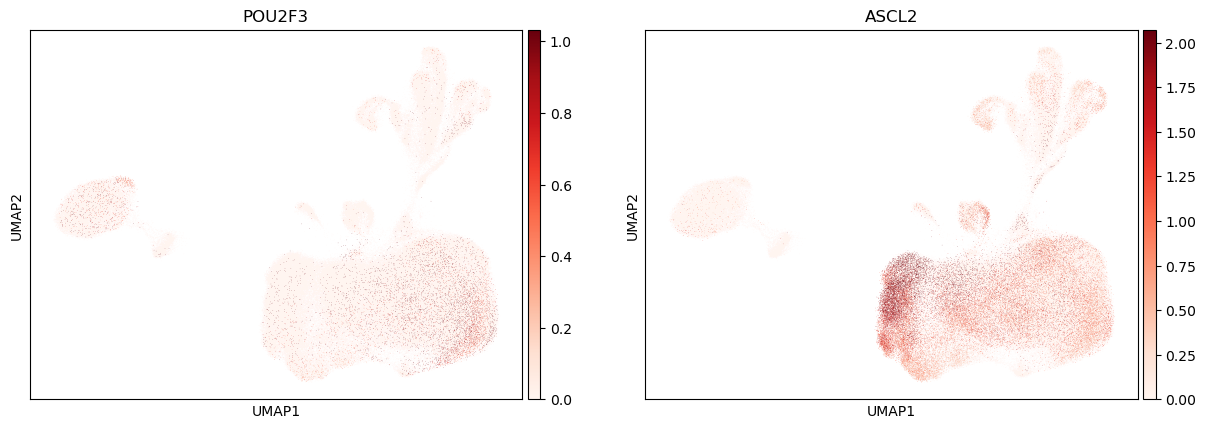

   ✓ Tuft markers UMAP saved


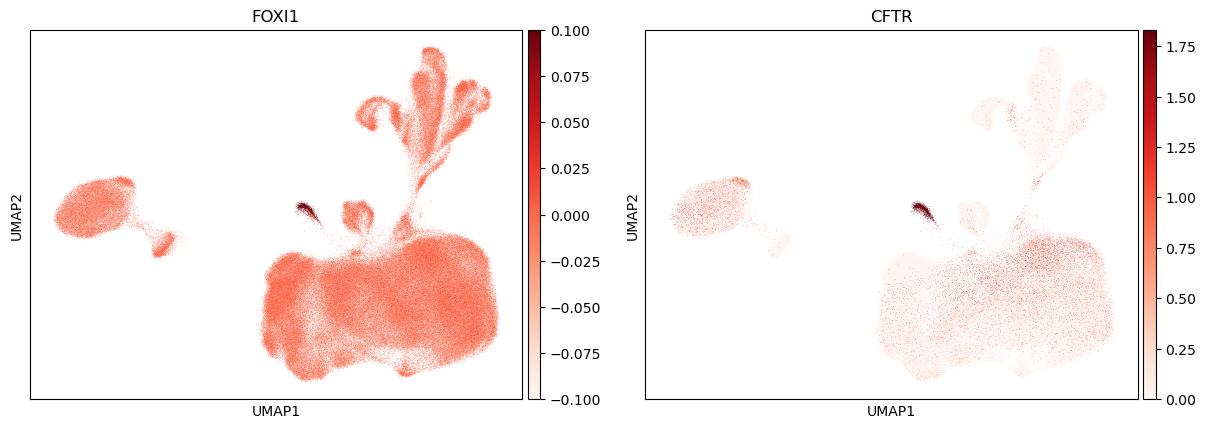

   ✓ Ionocyte markers UMAP saved


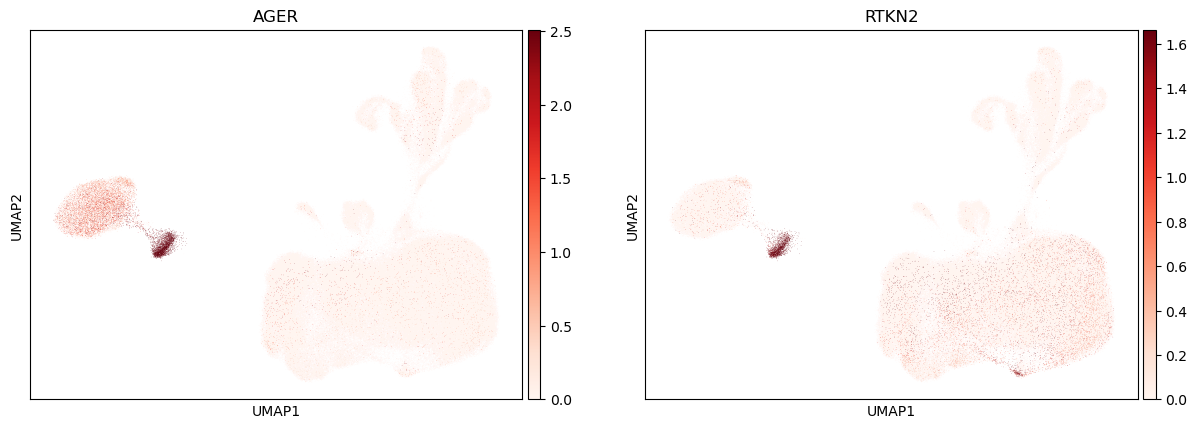

   ✓ AT1 markers UMAP saved


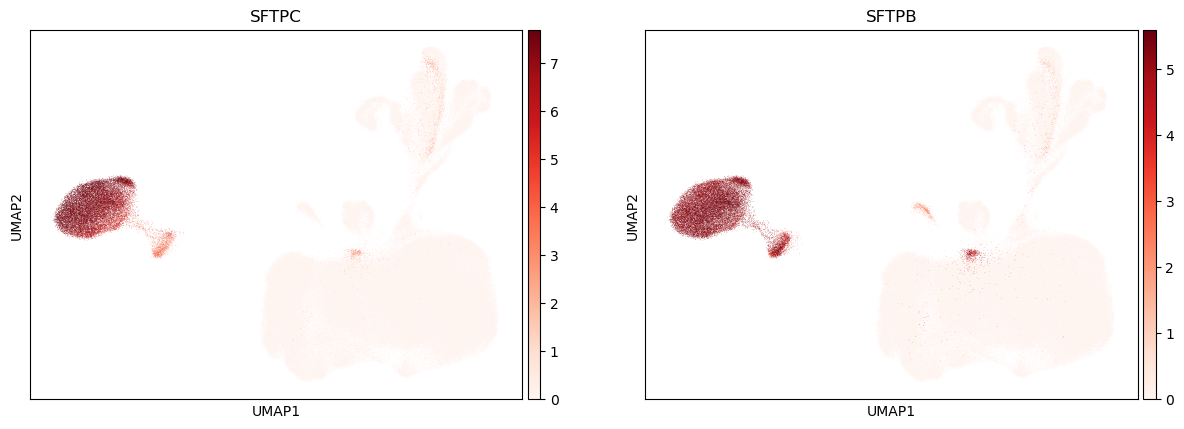

   ✓ AT2 markers UMAP saved


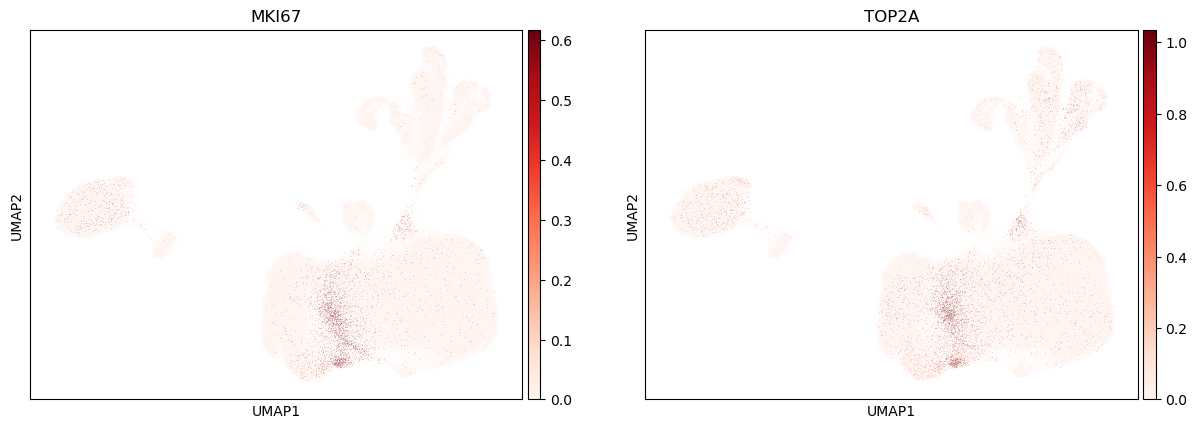

   ✓ Proliferating markers UMAP saved


In [29]:
if RUN_UMAP:
    # 3) Key marker expression UMAPs
    print("\n   Generating marker expression UMAPs...")
    for celltype, genes in KEY_MARKERS.items():
        available = [g for g in genes if (g in (adata_hvg.raw.var_names if adata_hvg.raw is not None else adata_hvg.var_names))]
        if available:
            sc.pl.umap(
                adata_hvg,
                color=available,
                use_raw=True,
                cmap='Reds',
                ncols=len(available),
                vmax='p99',
                save=f'_{celltype}_markers.{FIGURE_FORMAT}'
            )
            print(f"   ✓ {celltype} markers UMAP saved")


   Generating marker Dotplot...


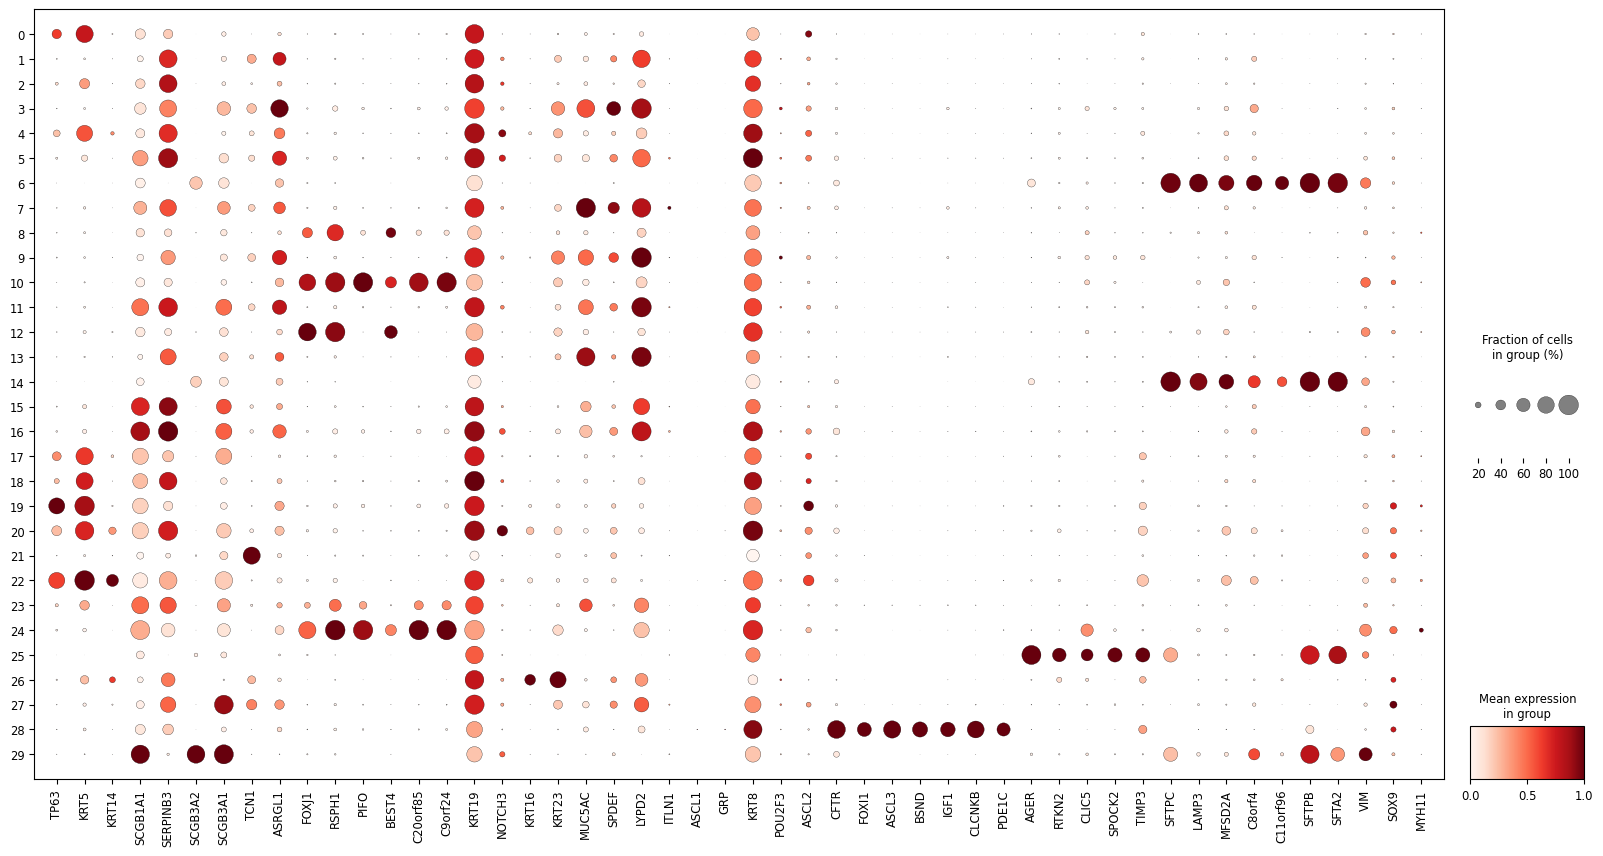

   ✓ Dotplot saved (showing 50 genes)


In [30]:
if RUN_UMAP and GENERATE_DOTPLOT and len(available_markers) > 0:
    # 4) Dotplot
    print("\n   Generating marker Dotplot...")
    try:
        markers_to_plot = available_markers[:50] if len(available_markers) > 50 else available_markers
        sc.pl.dotplot(
            adata_hvg,
            var_names=markers_to_plot,
            groupby='leiden_bbknn',
            standard_scale='var',
            use_raw=True,
            save=f'_epithelial_markers.{FIGURE_FORMAT}',
            figsize=(max(20, len(markers_to_plot)*0.4), 10)
        )
        print(f"   ✓ Dotplot saved (showing {len(markers_to_plot)} genes)")
    except Exception as e:
        print(f"   ⚠️ Dotplot generation failed: {e}")

In [31]:
if RUN_UMAP and GENERATE_HEATMAP and len(available_markers) > 0:
    # 5) Heatmap
    print("\n   Generating expression heatmap...")
    try:
        cluster_expr = pd.DataFrame()
        for gene in available_markers:
            if (adata_hvg.raw is not None) and (gene in adata_hvg.raw.var_names):
                Xg = adata_hvg.raw[:, gene].X
            elif gene in adata_hvg.var_names:
                Xg = adata_hvg[:, gene].X
            else:
                continue
            Xg = Xg.toarray().ravel() if hasattr(Xg, 'toarray') else np.asarray(Xg).ravel()
            cluster_expr[gene] = Xg
        cluster_expr['leiden_bbknn'] = adata_hvg.obs['leiden_bbknn'].values
        cluster_mean_expr = cluster_expr.groupby('leiden_bbknn').mean()
        plt.figure(figsize=(max(20, len(available_markers)*0.3), 10))
        sns.heatmap(
            cluster_mean_expr.T,
            cmap='RdYlBu_r',
            center=0,
            robust=True,
            yticklabels=True,
            xticklabels=True,
            cbar_kws={'label': 'Mean Expression'}
        )
        plt.title('Epithelial Marker Expression Across Clusters')
        plt.xlabel('Cluster')
        plt.ylabel('Marker Genes')
        plt.tight_layout()
        plt.savefig(fig_dir / f'heatmap_marker_expression.{FIGURE_FORMAT}', dpi=DPI, bbox_inches='tight')
        plt.close()
        print(f"   ✓ Heatmap saved")
    except Exception as e:
        print(f"   ⚠️ Heatmap generation failed: {e}")


   Generating expression heatmap...
   ✓ Heatmap saved


In [32]:
if RUN_UMAP and GENERATE_FACET_PLOTS and BATCH_KEY in adata_hvg.obs.columns:
    # 6) Batch facets
    print("\n   Generating batch-wise UMAP...")
    try:
        batches = sorted(adata_hvg.obs[BATCH_KEY].unique())
        n_batches = len(batches)
        n_cols = min(3, n_batches)
        n_rows = (n_batches + n_cols - 1) // n_cols
        
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 5*n_rows))
        axes = [axes] if n_batches == 1 else axes.flatten()
        
        for i, batch in enumerate(batches):
            adata_batch = adata_hvg[adata_hvg.obs[BATCH_KEY] == batch].copy()
            
            sc.pl.umap(
                adata_batch,
                color='leiden_bbknn',
                ax=axes[i],
                show=False,
                title=f'Batch: {batch}',
                legend_loc='right margin',
                legend_fontsize=6
            )
        
        for i in range(n_batches, len(axes)):
            axes[i].axis('off')
        
        plt.tight_layout()
        plt.savefig(fig_dir / f'umap_by_batch.{FIGURE_FORMAT}', dpi=DPI, bbox_inches='tight')
        plt.close()
        print(f"   ✓ Batch-wise UMAP saved")
    except Exception as e:
        print(f"   ⚠️ Batch-wise UMAP generation failed: {e}")


   Generating batch-wise UMAP...
   ✓ Batch-wise UMAP saved


In [33]:
if RUN_UMAP:
    print(f"\n   All figures saved to: {fig_dir}")


   All figures saved to: /home/h2048/data/py/1128/bbknn_celltype_analysis/Epithelial/output_optimized/figures


## Backfill Results to Full Dataset

In [ ]:
print("\nBackfilling results to full dataset...")

# Transfer results from HVG subset to full dataset
for key in ['X_pca','X_umap']:
    if key in adata_hvg.obsm:
        adata_full.obsm[key] = adata_hvg.obsm[key]

for col in adata_hvg.obs.columns:
    if col.startswith('leiden_bbknn'):
        adata_full.obs[col] = adata_hvg.obs[col]

if 'neighbors' in adata_hvg.uns:
    adata_full.uns['neighbors'] = adata_hvg.uns['neighbors']

if 'connectivities' in adata_hvg.obsp:
    adata_full.obsp['connectivities'] = adata_hvg.obsp['connectivities']

if 'distances' in adata_hvg.obsp:
    adata_full.obsp['distances'] = adata_hvg.obsp['distances']

print("   ✓ Results backfilled")

## Save Integrated Data

In [ ]:
print("\nSaving integrated AnnData...")
final_path = output_dir / "epithelial_bbknn_integrated.h5ad"
print("   Using gzip compression...")
adata_full.write_h5ad(final_path, compression='gzip', compression_opts=9)
file_size = final_path.stat().st_size / (1024**3)
print(f"   Saved: {final_path} ({file_size:.2f} GB)")

## Step 8: Generate Summary Report

In [ ]:
print("\n" + "="*70)
print("Step 8: Generate Summary Report")
print("="*70)

total_time = time.time() - start_time

report = []
report.append("="*70)
report.append("Epithelial Cell Analysis - BBKNN Integration Summary")
report.append("="*70)
report.append(f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
report.append(f"Processing time: {total_time:.1f} seconds ({total_time/60:.1f} minutes)")
report.append("")
report.append("[ Data Overview ]")
report.append(f"  Cells: {adata_full.n_obs:,}")
report.append(f"  Genes: {adata_full.n_vars:,}")
report.append("")

if BATCH_KEY in adata_full.obs.columns:
    report.append(f"[ Batch Distribution (key: {BATCH_KEY}) ]")
    batch_counts = adata_full.obs[BATCH_KEY].value_counts().sort_index()
    for batch, count in batch_counts.items():
        pct = count / adata_full.n_obs * 100
        report.append(f"  {batch}: {count:,} cells ({pct:.1f}%)")
    report.append("")

report.append("[ Epithelial Marker Genes ]")
report.append(f"  Total markers: {len(MARKER_EPITHELIAL)}")
report.append(f"  Available: {len(available_markers)} ({len(available_markers)/len(MARKER_EPITHELIAL)*100:.1f}%)")
report.append("")

if RUN_CLUSTERING:
    report.append("[ Multi-resolution Clustering Results ]")
    for res in LEIDEN_RESOLUTIONS:
        key = f'leiden_bbknn_res{res}'
        if key in adata_full.obs.columns:
            n_clusters = adata_full.obs[key].nunique()
            default_marker = " (default)" if res == DEFAULT_RESOLUTION else ""
            report.append(f"  Resolution {res}: {n_clusters} clusters{default_marker}")
    report.append("")

report.append("[ BBKNN Configuration ]")
report.append(f"  neighbors_within_batch: {BBKNN_NEIGHBORS_WITHIN_BATCH}")
report.append(f"  n_pcs: {BBKNN_N_PCS}")
report.append(f"  batch_key: {BATCH_KEY}")
report.append(f"  High variable genes: {USE_HVG} (n={N_TOP_GENES if USE_HVG else 'N/A'})")
report.append("")

report.append("[ Output Files ]")
report.append(f"  - Data: {final_path}")
if RUN_UMAP:
    report.append(f"  - Figures: {output_dir / 'figures/'}*.{FIGURE_FORMAT}")
if RUN_FIND_MARKERS:
    report.append(f"  - Markers: {output_dir / 'cluster_markers.csv'}")
report.append("")

report.append("="*70)
report.append("Analysis completed successfully")
report.append("="*70)

report_text = '\n'.join(report)
report_path = output_dir / "analysis_summary.txt"
with open(report_path, 'w') as f:
    f.write(report_text)

print(f"\nReport saved to: {report_path}")
print("\n" + report_text)

## Final Summary

In [ ]:
print("\n" + "="*70)
print("✓ All analyses completed successfully")
print("="*70)
print(f"\nOutput directory: {output_dir}")
print(f"Data: {final_path} ({file_size:.2f} GB)")
if RUN_UMAP:
    print(f"Figures: {output_dir / 'figures/'}*.{FIGURE_FORMAT}")
if RUN_FIND_MARKERS:
    print(f"Markers: {output_dir / 'cluster_markers.csv'}")
print(f"\nTotal time: {total_time:.1f} seconds ({total_time/60:.1f} minutes)")

print(f"\n📊 Key Information:")
print(f"   Cells: {adata_full.n_obs:,}")
print(f"   Available markers: {len(available_markers)}/{len(MARKER_EPITHELIAL)}")
if RUN_CLUSTERING:
    print(f"   Default clusters: {adata_full.obs['leiden_bbknn'].nunique()}")

print(f"\n🔧 BBKNN Parameters:")
print(f"   neighbors_within_batch: {BBKNN_NEIGHBORS_WITHIN_BATCH}")
print(f"   n_pcs: {BBKNN_N_PCS}")
print(f"   HVG: {N_TOP_GENES}")
print()

---

# Alternative: Harmony Batch Correction

This section demonstrates an alternative batch correction approach using Harmony.  
Unlike BBKNN which builds batch-balanced neighbor graphs, Harmony corrects the principal components directly.

In [34]:
# Harmony-specific parameters
HARMONY_BATCH_KEY = 'sample'  # Use same batch key as BBKNN
HARMONY_MAX_ITER = 20
HARMONY_THETA = 2.0  # Diversity clustering penalty (higher = more aggressive correction)

# Whether to run Harmony analysis
RUN_HARMONY = True

print(f"Harmony configuration:")
print(f"   batch_key: {HARMONY_BATCH_KEY}")
print(f"   max_iter: {HARMONY_MAX_ITER}")
print(f"   theta: {HARMONY_THETA}")

Harmony configuration:
   batch_key: sample
   max_iter: 20
   theta: 2.0


## Install and Import Harmony (if needed)

In [35]:
if RUN_HARMONY:
    try:
        import harmonypy as hm
        print(f"harmonypy version: {hm.__version__}")
    except ImportError:
        print("harmonypy not found. Installing...")
        import subprocess
        subprocess.check_call([sys.executable, "-m", "pip", "install", "harmonypy"])
        import harmonypy as hm
        print(f"harmonypy installed successfully: {hm.__version__}")

harmonypy version: 0.0.10


## Prepare Data for Harmony

Harmony works on the PCA space, so we'll use the same preprocessed data

In [36]:
if RUN_HARMONY:
    print("\n" + "="*70)
    print("Harmony Batch Correction Pipeline")
    print("="*70)
    
    # Create a copy for Harmony analysis
    adata_harmony = adata_hvg.copy()
    print(f"\nCreated Harmony working copy:")
    print(f"   Cells: {adata_harmony.n_obs:,}")
    print(f"   Genes: {adata_harmony.n_vars:,}")
    print(f"   PCA components: {adata_harmony.obsm['X_pca'].shape[1]}")


Harmony Batch Correction Pipeline

Created Harmony working copy:
   Cells: 278,930
   Genes: 2,017
   PCA components: 50


## Run Harmony on PCA

In [37]:
if RUN_HARMONY:
    print("\nRunning Harmony batch correction...")
    print(f"   Correcting for: {HARMONY_BATCH_KEY}")
    
    harmony_start = time.time()
    
    # Use scanpy's harmony integration
    sc.external.pp.harmony_integrate(
        adata_harmony,
        key=HARMONY_BATCH_KEY,
        basis='X_pca',
        adjusted_basis='X_pca_harmony',
        max_iter_harmony=HARMONY_MAX_ITER,
        theta=HARMONY_THETA
    )
    
    harmony_time = time.time() - harmony_start
    print(f"\n   Harmony complete, time elapsed: {harmony_time:.1f} seconds")
    print(f"   Corrected PCs stored in: .obsm['X_pca_harmony']")


Running Harmony batch correction...
   Correcting for: sample


2025-11-30 21:04:58,540 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-11-30 21:08:25,273 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-11-30 21:08:27,365 - harmonypy - INFO - Iteration 1 of 20
2025-11-30 21:19:04,591 - harmonypy - INFO - Iteration 2 of 20
2025-11-30 21:30:16,963 - harmonypy - INFO - Iteration 3 of 20
2025-11-30 21:41:30,489 - harmonypy - INFO - Iteration 4 of 20
2025-11-30 21:52:39,270 - harmonypy - INFO - Iteration 5 of 20
2025-11-30 22:03:13,380 - harmonypy - INFO - Converged after 5 iterations



   Harmony complete, time elapsed: 3495.6 seconds
   Corrected PCs stored in: .obsm['X_pca_harmony']


## Compute UMAP on Harmony-corrected PCs

In [38]:
if RUN_HARMONY:
    print("\nComputing neighbor graph on Harmony-corrected PCs...")
    
    # Compute neighbors using Harmony-corrected PCs
    sc.pp.neighbors(
        adata_harmony,
        n_neighbors=15,
        n_pcs=BBKNN_N_PCS,
        use_rep='X_pca_harmony'
    )
    
    print("   Neighbor graph computed")
    
    # Compute UMAP
    print(f"\nRunning UMAP on Harmony PCs (min_dist={UMAP_MIN_DIST})...")
    sc.tl.umap(adata_harmony, min_dist=UMAP_MIN_DIST)
    print("   UMAP complete")


Computing neighbor graph on Harmony-corrected PCs...
   Neighbor graph computed

Running UMAP on Harmony PCs (min_dist=0.5)...
   UMAP complete


## Clustering on Harmony-corrected Data

In [39]:
if RUN_HARMONY and RUN_CLUSTERING:
    print("\nRunning multi-resolution Leiden clustering on Harmony data...")
    print(f"   Resolution list: {LEIDEN_RESOLUTIONS}")
    
    for res in LEIDEN_RESOLUTIONS:
        cluster_key = f'leiden_harmony_res{res}'
        try:
            sc.tl.leiden(
                adata_harmony,
                resolution=res,
                key_added=cluster_key,
                flavor='igraph',
                n_iterations=2,
                directed=False
            )
        except TypeError:
            sc.tl.leiden(
                adata_harmony,
                resolution=res,
                key_added=cluster_key,
                n_iterations=2
            )
        n_clusters = adata_harmony.obs[cluster_key].nunique()
        print(f"   Resolution {res}: {n_clusters} clusters")
    
    # Set default clustering
    default_key = f'leiden_harmony_res{DEFAULT_RESOLUTION}'
    adata_harmony.obs['leiden_harmony'] = adata_harmony.obs[default_key]
    print(f"\n   Default clustering: {default_key}")


Running multi-resolution Leiden clustering on Harmony data...
   Resolution list: [1.2, 1.6, 2.0, 2.4, 2.8]
   Resolution 1.2: 25 clusters
   Resolution 1.6: 28 clusters
   Resolution 2.0: 36 clusters
   Resolution 2.4: 41 clusters
   Resolution 2.8: 45 clusters

   Default clustering: leiden_harmony_res2.0


## Compare BBKNN vs Harmony Integration Quality

In [40]:
if RUN_HARMONY:
    print("\n" + "="*70)
    print("Comparison: BBKNN vs Harmony")
    print("="*70)
    
    # Compare cluster numbers
    bbknn_clusters = adata_hvg.obs['leiden_bbknn'].nunique()
    harmony_clusters = adata_harmony.obs['leiden_harmony'].nunique()
    
    print(f"\nClustering results (resolution={DEFAULT_RESOLUTION}):")
    print(f"   BBKNN:   {bbknn_clusters} clusters")
    print(f"   Harmony: {harmony_clusters} clusters")
    
    # Compare batch distribution
    print(f"\nBatch distribution across clusters:")
    print(f"\nBBKNN:")
    bbknn_batch_dist = pd.crosstab(
        adata_hvg.obs['leiden_bbknn'],
        adata_hvg.obs[BATCH_KEY],
        normalize='index'
    )
    print(bbknn_batch_dist.round(3))
    
    print(f"\nHarmony:")
    harmony_batch_dist = pd.crosstab(
        adata_harmony.obs['leiden_harmony'],
        adata_harmony.obs[BATCH_KEY],
        normalize='index'
    )
    print(harmony_batch_dist.round(3))


Comparison: BBKNN vs Harmony

Clustering results (resolution=2.0):
   BBKNN:   30 clusters
   Harmony: 36 clusters

Batch distribution across clusters:

BBKNN:
dataset       Banovich_Kropski_2020  Barbry_Leroy_2020  Guanrui_Liao_2025  \
leiden_bbknn                                                                
0                             0.000              0.331              0.007   
1                             0.000              0.151              0.000   
2                             0.001              0.142              0.004   
3                             0.000              0.070              0.002   
4                             0.000              0.194              0.009   
5                             0.001              0.016              0.023   
6                             0.222              0.000              0.000   
7                             0.001              0.061              0.019   
8                             0.059              0.018              0

## Visualize Harmony Results

In [41]:
if RUN_HARMONY:
    print("\nGenerating Harmony visualization...")
    
    harmony_fig_dir = output_dir / "figures_harmony"
    harmony_fig_dir.mkdir(exist_ok=True)
    
    # Overview comparison plot
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # Row 1: BBKNN results
    sc.pl.umap(adata_hvg, color=BATCH_KEY, ax=axes[0,0], show=False, title='BBKNN - Batch')
    sc.pl.umap(adata_hvg, color='leiden_bbknn', ax=axes[0,1], show=False,
               title='BBKNN - Clusters', legend_loc='on data', legend_fontsize=6)
    if 'cell_type' in adata_hvg.obs.columns:
        sc.pl.umap(adata_hvg, color='cell_type', ax=axes[0,2], show=False, title='BBKNN - Cell Type')
    else:
        axes[0,2].axis('off')
    
    # Row 2: Harmony results
    sc.pl.umap(adata_harmony, color=BATCH_KEY, ax=axes[1,0], show=False, title='Harmony - Batch')
    sc.pl.umap(adata_harmony, color='leiden_harmony', ax=axes[1,1], show=False,
               title='Harmony - Clusters', legend_loc='on data', legend_fontsize=6)
    if 'cell_type' in adata_harmony.obs.columns:
        sc.pl.umap(adata_harmony, color='cell_type', ax=axes[1,2], show=False, title='Harmony - Cell Type')
    else:
        axes[1,2].axis('off')
    
    plt.tight_layout()
    plt.savefig(harmony_fig_dir / f'comparison_bbknn_vs_harmony.{FIGURE_FORMAT}',
                dpi=DPI, bbox_inches='tight')
    plt.close()
    
    print(f"   ✓ Comparison plot saved to {harmony_fig_dir}")


Generating Harmony visualization...
   ✓ Comparison plot saved to /home/h2048/data/py/1128/bbknn_celltype_analysis/Epithelial/output_optimized/figures_harmony


## Harmony Multi-resolution Clustering Visualization

In [42]:
if RUN_HARMONY and RUN_CLUSTERING and len(LEIDEN_RESOLUTIONS) > 1:
    print("\nGenerating Harmony multi-resolution clustering plots...")
    
    n_res = len(LEIDEN_RESOLUTIONS)
    n_cols = 3
    n_rows = (n_res + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 6*n_rows))
    axes = axes.flatten() if n_res > 1 else [axes]
    
    for i, res in enumerate(LEIDEN_RESOLUTIONS):
        cluster_key = f'leiden_harmony_res{res}'
        sc.pl.umap(
            adata_harmony,
            color=cluster_key,
            ax=axes[i],
            show=False,
            title=f'Harmony - Resolution {res}',
            legend_loc='on data',
            legend_fontsize=8
        )
    
    for i in range(n_res, len(axes)):
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.savefig(harmony_fig_dir / f'harmony_resolutions.{FIGURE_FORMAT}',
                dpi=DPI, bbox_inches='tight')
    plt.close()
    
    print(f"   ✓ Multi-resolution plot saved")


Generating Harmony multi-resolution clustering plots...
   ✓ Multi-resolution plot saved


## Harmony Marker Expression Visualization


Generating Harmony marker expression UMAPs...


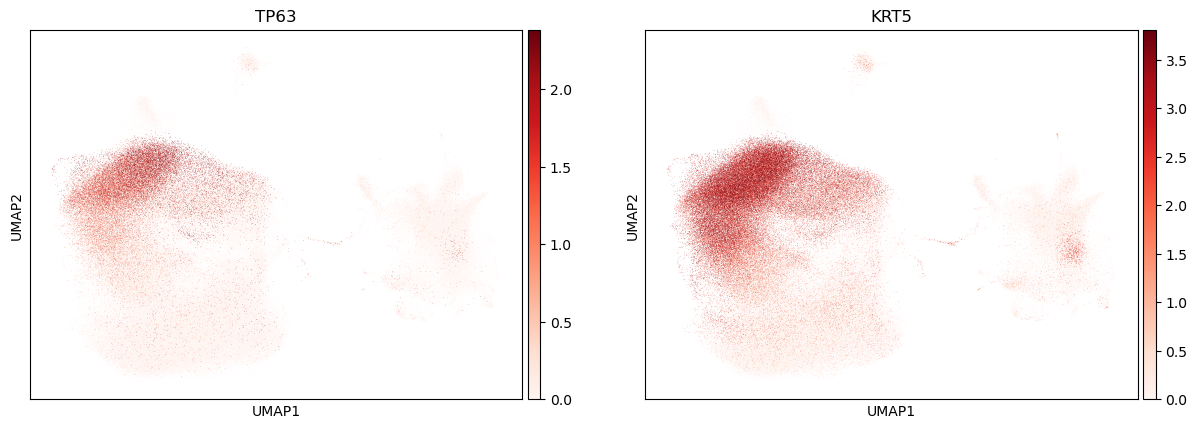

   ✓ Basal markers UMAP saved


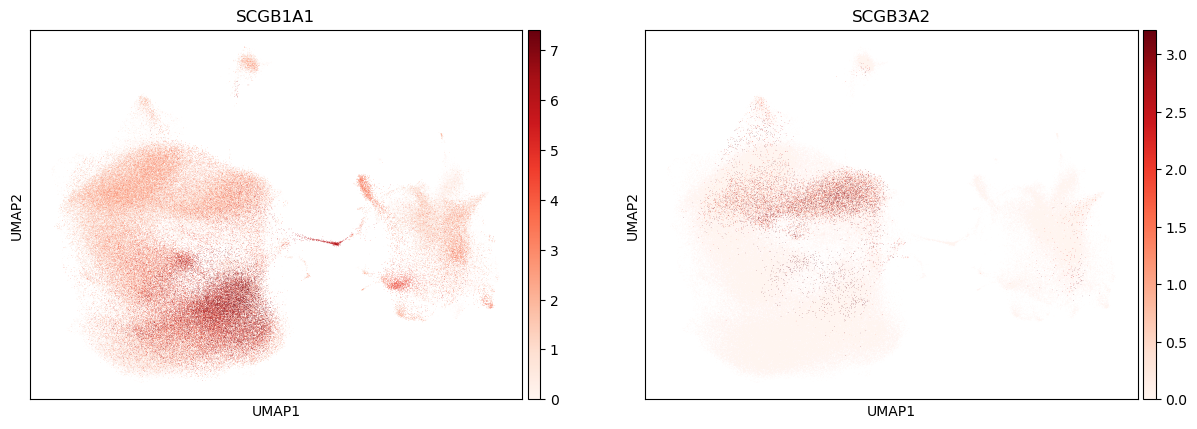

   ✓ Secretory markers UMAP saved


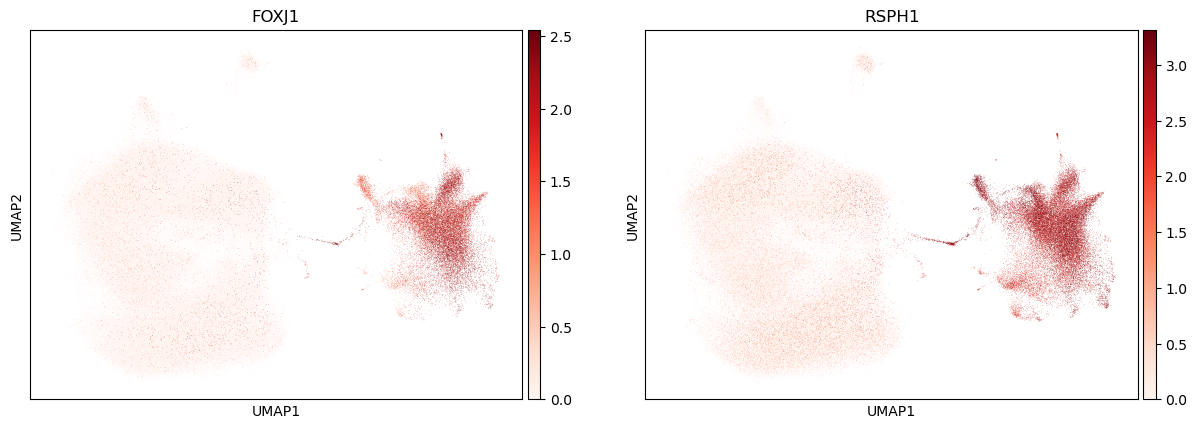

   ✓ Ciliated markers UMAP saved


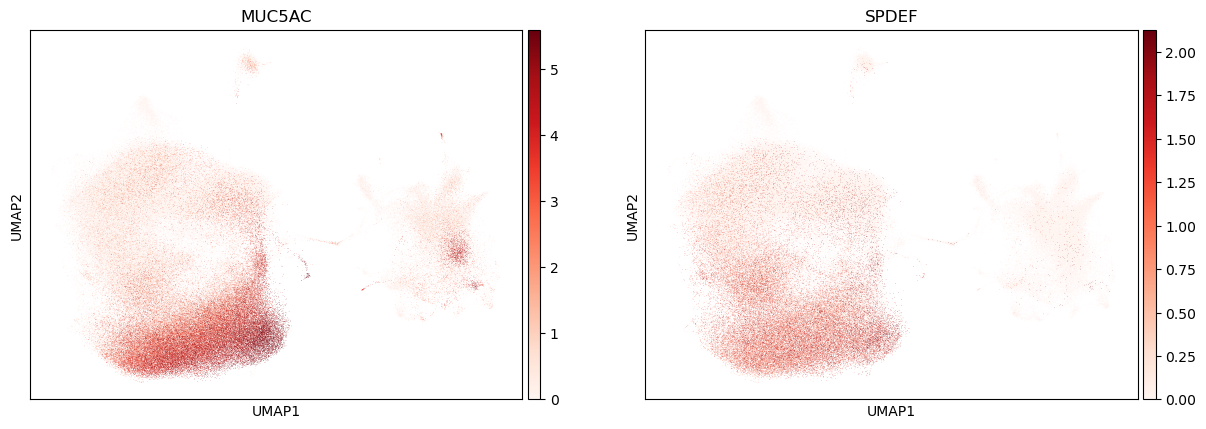

   ✓ Goblet markers UMAP saved


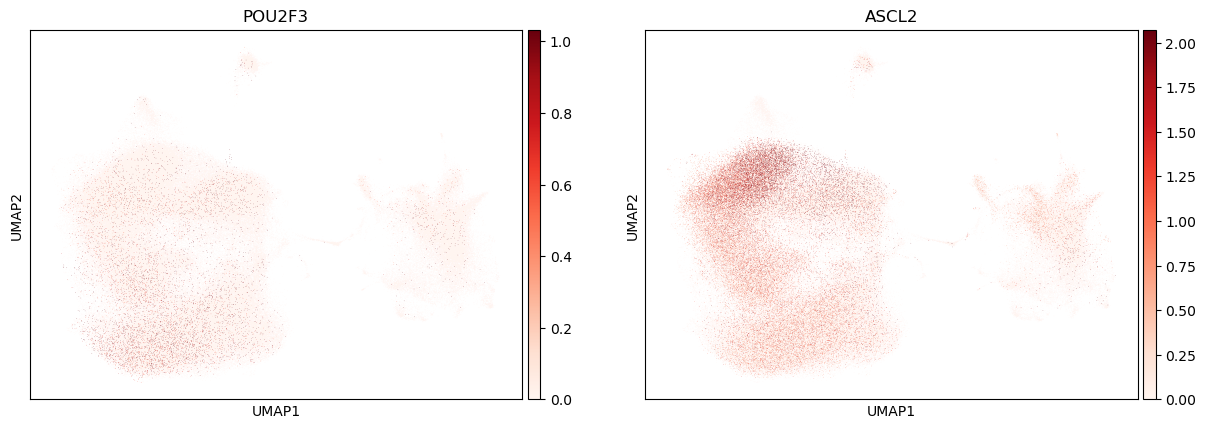

   ✓ Tuft markers UMAP saved


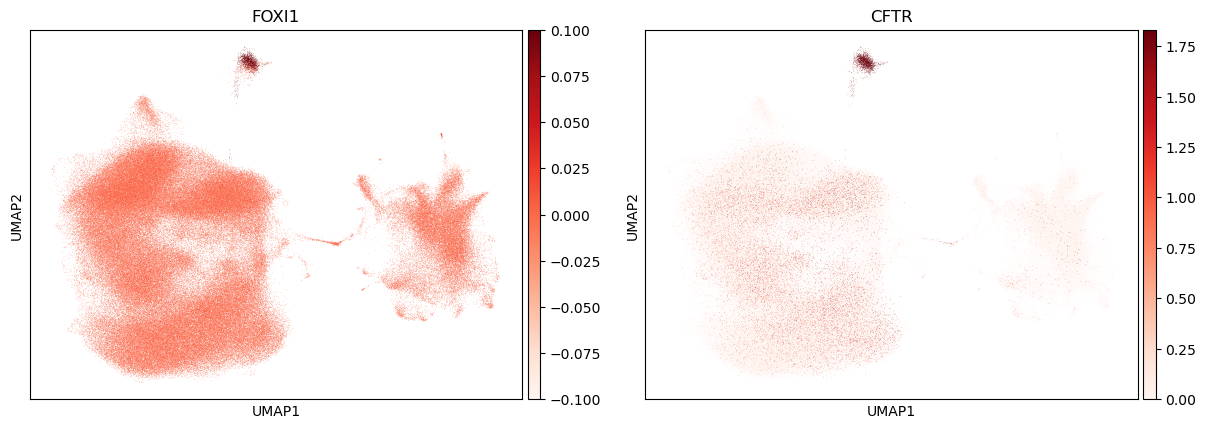

   ✓ Ionocyte markers UMAP saved


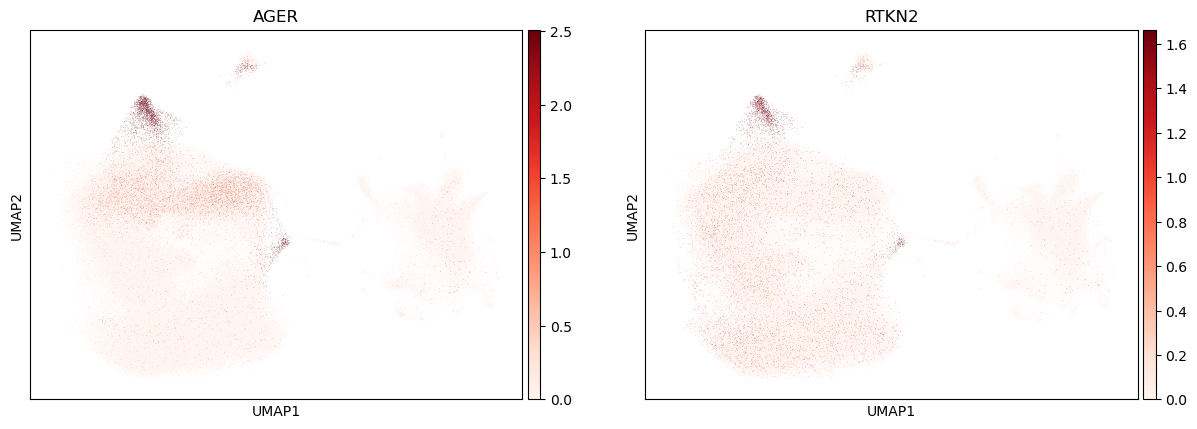

   ✓ AT1 markers UMAP saved


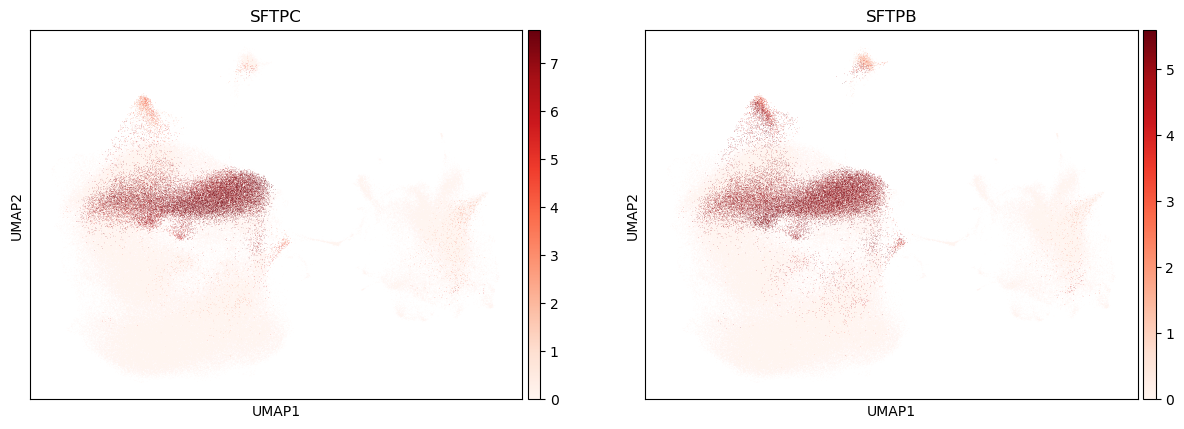

   ✓ AT2 markers UMAP saved


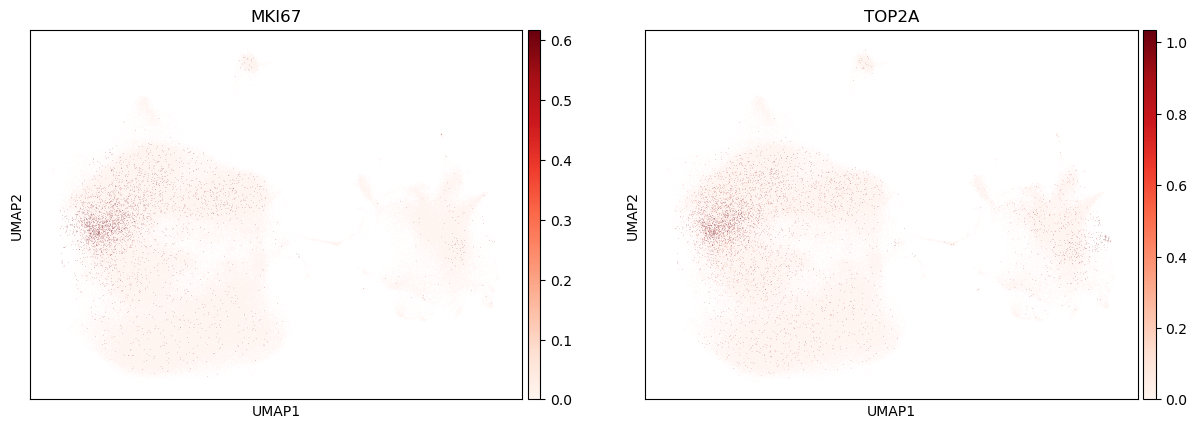

   ✓ Proliferating markers UMAP saved


In [43]:
if RUN_HARMONY:
    print("\nGenerating Harmony marker expression UMAPs...")
    
    # Set figure directory for scanpy
    sc.settings.figdir = harmony_fig_dir
    
    for celltype, genes in KEY_MARKERS.items():
        available = [g for g in genes if (g in (adata_harmony.raw.var_names if adata_harmony.raw is not None else adata_harmony.var_names))]
        if available:
            sc.pl.umap(
                adata_harmony,
                color=available,
                use_raw=True,
                cmap='Reds',
                ncols=len(available),
                vmax='p99',
                save=f'_harmony_{celltype}_markers.{FIGURE_FORMAT}'
            )
            print(f"   ✓ {celltype} markers UMAP saved")
    
    # Reset figdir
    sc.settings.figdir = output_dir / "figures"

## Harmony Batch-wise Facet Plot

In [44]:
if RUN_HARMONY and GENERATE_FACET_PLOTS and BATCH_KEY in adata_harmony.obs.columns:
    print("\nGenerating Harmony batch-wise UMAP...")
    
    try:
        batches = sorted(adata_harmony.obs[BATCH_KEY].unique())
        n_batches = len(batches)
        n_cols = min(3, n_batches)
        n_rows = (n_batches + n_cols - 1) // n_cols
        
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 5*n_rows))
        axes = [axes] if n_batches == 1 else axes.flatten()
        
        for i, batch in enumerate(batches):
            adata_batch = adata_harmony[adata_harmony.obs[BATCH_KEY] == batch].copy()
            
            sc.pl.umap(
                adata_batch,
                color='leiden_harmony',
                ax=axes[i],
                show=False,
                title=f'Harmony - Batch: {batch}',
                legend_loc='right margin',
                legend_fontsize=6
            )
        
        for i in range(n_batches, len(axes)):
            axes[i].axis('off')
        
        plt.tight_layout()
        plt.savefig(harmony_fig_dir / f'harmony_umap_by_batch.{FIGURE_FORMAT}',
                    dpi=DPI, bbox_inches='tight')
        plt.close()
        
        print(f"   ✓ Batch-wise UMAP saved")
    except Exception as e:
        print(f"   ⚠️ Batch-wise UMAP generation failed: {e}")


Generating Harmony batch-wise UMAP...
   ✓ Batch-wise UMAP saved


## Save Harmony Results

In [45]:
if RUN_HARMONY:
    print("\nBackfilling Harmony results to full dataset...")
    
    # Transfer Harmony results to full dataset
    adata_full.obsm['X_pca_harmony'] = adata_harmony.obsm['X_pca_harmony']
    adata_full.obsm['X_umap_harmony'] = adata_harmony.obsm['X_umap']
    
    for col in adata_harmony.obs.columns:
        if col.startswith('leiden_harmony'):
            adata_full.obs[col] = adata_harmony.obs[col]
    
    print("   ✓ Harmony results backfilled")
    
    # Save Harmony-integrated data
    print("\nSaving Harmony-integrated AnnData...")
    harmony_path = output_dir / "epithelial_harmony_integrated.h5ad"
    print("   Using gzip compression...")
    adata_full.write_h5ad(harmony_path, compression='gzip', compression_opts=9)
    harmony_file_size = harmony_path.stat().st_size / (1024**3)
    print(f"   Saved: {harmony_path} ({harmony_file_size:.2f} GB)")


Backfilling Harmony results to full dataset...
   ✓ Harmony results backfilled

Saving Harmony-integrated AnnData...
   Using gzip compression...


KeyboardInterrupt: 

## Harmony Summary Report

In [ ]:
if RUN_HARMONY:
    print("\n" + "="*70)
    print("Harmony Integration Summary")
    print("="*70)
    
    harmony_report = []
    harmony_report.append("="*70)
    harmony_report.append("Epithelial Cell Analysis - Harmony Integration Summary")
    harmony_report.append("="*70)
    harmony_report.append(f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    harmony_report.append(f"Harmony processing time: {harmony_time:.1f} seconds")
    harmony_report.append("")
    
    harmony_report.append("[ Harmony Configuration ]")
    harmony_report.append(f"  batch_key: {HARMONY_BATCH_KEY}")
    harmony_report.append(f"  max_iter: {HARMONY_MAX_ITER}")
    harmony_report.append(f"  theta: {HARMONY_THETA}")
    harmony_report.append(f"  n_pcs: {BBKNN_N_PCS}")
    harmony_report.append("")
    
    harmony_report.append("[ Clustering Results ]")
    harmony_report.append(f"  Default resolution: {DEFAULT_RESOLUTION}")
    harmony_report.append(f"  Harmony clusters: {adata_full.obs['leiden_harmony'].nunique()}")
    harmony_report.append(f"  BBKNN clusters: {adata_full.obs['leiden_bbknn'].nunique()}")
    harmony_report.append("")
    
    harmony_report.append("[ Output Files ]")
    harmony_report.append(f"  - Data: {harmony_path}")
    harmony_report.append(f"  - Figures: {harmony_fig_dir}/*.{FIGURE_FORMAT}")
    harmony_report.append("")
    
    harmony_report.append("="*70)
    harmony_report.append("Harmony analysis completed successfully")
    harmony_report.append("="*70)
    
    harmony_report_text = '\n'.join(harmony_report)
    harmony_report_path = output_dir / "harmony_summary.txt"
    with open(harmony_report_path, 'w') as f:
        f.write(harmony_report_text)
    
    print(f"\nHarmony report saved to: {harmony_report_path}")
    print("\n" + harmony_report_text)

## Final Summary: BBKNN + Harmony

In [ ]:
if RUN_HARMONY:
    print("\n" + "="*70)
    print("✓ Complete Pipeline (BBKNN + Harmony) Finished")
    print("="*70)
    
    total_pipeline_time = time.time() - start_time
    
    print(f"\n📊 Final Results Summary:")
    print(f"   Total cells: {adata_full.n_obs:,}")
    print(f"   Total genes: {adata_full.n_vars:,}")
    print(f"   Available markers: {len(available_markers)}/{len(MARKER_EPITHELIAL)}")
    print(f"\n   BBKNN clusters (res={DEFAULT_RESOLUTION}): {adata_full.obs['leiden_bbknn'].nunique()}")
    print(f"   Harmony clusters (res={DEFAULT_RESOLUTION}): {adata_full.obs['leiden_harmony'].nunique()}")
    
    print(f"\n⏱️  Processing Times:")
    print(f"   BBKNN integration: {bbknn_time:.1f} seconds")
    print(f"   Harmony integration: {harmony_time:.1f} seconds")
    print(f"   Total pipeline: {total_pipeline_time:.1f} seconds ({total_pipeline_time/60:.1f} minutes)")
    
    print(f"\n💾 Output Files:")
    print(f"   BBKNN results: {final_path}")
    print(f"   Harmony results: {harmony_path}")
    print(f"   BBKNN figures: {output_dir / 'figures/'}")
    print(f"   Harmony figures: {harmony_fig_dir}")
    
    print(f"\n📝 Recommendation:")
    print(f"   Compare the batch mixing and clustering quality between BBKNN and Harmony")
    print(f"   Check batch distribution plots and UMAP visualizations")
    print(f"   Choose the method that best preserves biological signal while removing batch effects")
    print()

---

# cNMF (consensus Non-negative Matrix Factorization) Analysis

This section runs cNMF to identify gene expression programs (GEPs) in epithelial cells.  
We'll run cNMF on both:
1. **Uncorrected data** - to see batch effects
2. **Harmony-corrected data** - using the two-stage approach (corrected for usage, uncorrected for spectra)

## Install and Import cNMF

In [46]:
# Install cnmf if needed
try:
    from cnmf import cNMF
    print("cNMF already installed")
except ImportError:
    print("Installing cNMF...")
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "cnmf"])
    from cnmf import cNMF
    print("cNMF installed successfully")

cNMF already installed


## cNMF Configuration

In [47]:
# cNMF parameters
RUN_CNMF = True
CNMF_OUTPUT_DIR = output_dir / "cnmf_results"
CNMF_OUTPUT_DIR.mkdir(exist_ok=True)

# cNMF settings
CNMF_COMPONENTS = [10, 15, 20, 25, 30]  # Test multiple K values
CNMF_N_ITER = 100  # Number of NMF replicates
CNMF_SEED = 14
CNMF_NUM_HVG = 2000  # Number of high variance genes
CNMF_DENSITY_THRESHOLD = 0.1  # For consensus clustering

print(f"cNMF Configuration:")
print(f"   Output directory: {CNMF_OUTPUT_DIR}")
print(f"   Components to test: {CNMF_COMPONENTS}")
print(f"   Iterations per K: {CNMF_N_ITER}")
print(f"   HVG count: {CNMF_NUM_HVG}")
print(f"   Density threshold: {CNMF_DENSITY_THRESHOLD}")

cNMF Configuration:
   Output directory: /home/h2048/data/py/1128/bbknn_celltype_analysis/Epithelial/output_optimized/cnmf_results
   Components to test: [10, 15, 20, 25, 30]
   Iterations per K: 100
   HVG count: 2000
   Density threshold: 0.1


## Prepare Data for cNMF

We need to save the data in formats cNMF can read

In [48]:
if RUN_CNMF:
    print("\n" + "="*70)
    print("Preparing data for cNMF")
    print("="*70)
    
    # Use the original full data (before any batch correction)
    # We need raw counts for cNMF
    cnmf_data_path = CNMF_OUTPUT_DIR / "epithelial_raw_counts.h5ad"
    
    # Create a clean AnnData with raw counts
    adata_cnmf = adata_full.copy()
    
    # Make sure we have raw counts in X
    if 'counts' in adata_cnmf.layers:
        adata_cnmf.X = adata_cnmf.layers['counts'].copy()
        print(f"   Using counts from layers['counts']")
    else:
        print(f"   Warning: No counts layer found, using current X")
    
    # Save for cNMF
    adata_cnmf.write_h5ad(cnmf_data_path)
    print(f"   Saved raw counts to: {cnmf_data_path}")
    print(f"   Shape: {adata_cnmf.n_obs} cells × {adata_cnmf.n_vars} genes")


Preparing data for cNMF
   Using counts from layers['counts']
   Saved raw counts to: /home/h2048/data/py/1128/bbknn_celltype_analysis/Epithelial/output_optimized/cnmf_results/epithelial_raw_counts.h5ad
   Shape: 278930 cells × 53973 genes


## Run cNMF without Batch Correction (Baseline)

First, let's run cNMF on uncorrected data to see the batch effects

In [49]:
if RUN_CNMF:
    print("\n" + "="*70)
    print("cNMF Analysis - WITHOUT Batch Correction")
    print("="*70)
    
    cnmf_nocorr = cNMF(output_dir=str(CNMF_OUTPUT_DIR), name='Epithelial_NoBatchCorrection')
    
    print("\nStep 1: Prepare...")
    cnmf_nocorr.prepare(
        counts_fn=str(cnmf_data_path),
        components=CNMF_COMPONENTS,
        n_iter=CNMF_N_ITER,
        seed=CNMF_SEED,
        num_highvar_genes=CNMF_NUM_HVG
    )
    print("   ✓ Preparation complete")


cNMF Analysis - WITHOUT Batch Correction

Step 1: Prepare...


KeyboardInterrupt: 

In [ ]:
if RUN_CNMF:
    print("\nStep 2: Factorize (this may take a while)...")
    print(f"   Running {CNMF_N_ITER} iterations for each K in {CNMF_COMPONENTS}")
    
    factorize_start = time.time()
    cnmf_nocorr.factorize(worker_i=0, total_workers=1)
    factorize_time = time.time() - factorize_start
    
    print(f"   ✓ Factorization complete ({factorize_time:.1f} seconds)")

In [ ]:
if RUN_CNMF:
    print("\nStep 3: Combine results...")
    cnmf_nocorr.combine()
    print("   ✓ Results combined")

In [ ]:
if RUN_CNMF:
    print("\nStep 4: Consensus clustering for each K...")
    
    for k in CNMF_COMPONENTS:
        print(f"\n   Processing K={k}...")
        cnmf_nocorr.consensus(
            k=k,
            density_threshold=CNMF_DENSITY_THRESHOLD,
            show_clustering=True,
            close_clustergram_fig=True
        )
        print(f"   ✓ K={k} consensus complete")

## Select Optimal K and Load Results (No Correction)

In [ ]:
if RUN_CNMF:
    # Choose K based on stability metrics
    # For this example, we'll use K=15 (you should examine the plots to choose)
    SELECTED_K = 15
    
    print(f"\nLoading cNMF results for K={SELECTED_K} (no batch correction)...")
    
    (usage_nocorr, spectra_scores_nocorr, 
     spectra_tpm_nocorr, top_genes_nocorr) = cnmf_nocorr.load_results(
        K=SELECTED_K,
        density_threshold=CNMF_DENSITY_THRESHOLD
    )
    
    print(f"   Usage matrix shape: {usage_nocorr.shape}")
    print(f"   Spectra shape: {spectra_tpm_nocorr.shape}")
    print(f"\n   First few cells:")
    print(usage_nocorr.head())

## Visualize GEP Usage by Batch (No Correction)

This will show batch effects in the uncorrected data

In [ ]:
if RUN_CNMF:
    print("\nVisualizing GEP usage by batch (uncorrected data)...")
    
    # Prepare data for plotting
    usage_plot_nocorr = usage_nocorr.unstack().reset_index()
    usage_plot_nocorr = pd.merge(
        left=usage_plot_nocorr,
        right=adata_full.obs[[BATCH_KEY, 'leiden_bbknn']],
        left_on='level_1',
        right_index=True
    )
    usage_plot_nocorr.columns = ['GEP', 'cell', 'Usage', 'Batch', 'Cluster']
    
    # Get unique clusters
    clusters = sorted(adata_full.obs['leiden_bbknn'].unique())
    
    # Plot
    fig, axes = plt.subplots(
        len(clusters), 1,
        figsize=(12, len(clusters)*1.5),
        dpi=150,
        gridspec_kw={'hspace': 0.8}
    )
    
    if len(clusters) == 1:
        axes = [axes]
    
    for i, cluster in enumerate(clusters):
        cluster_data = usage_plot_nocorr[usage_plot_nocorr['Cluster'] == cluster]
        sns.boxplot(
            x='GEP', y='Usage', hue='Batch',
            data=cluster_data,
            ax=axes[i],
            fliersize=1
        )
        axes[i].set_title(f'Cluster {cluster}')
        axes[i].set_xlabel('')
        axes[i].set_ylabel('Usage')
        
        if i != (len(clusters)-1):
            axes[i].set_xticklabels([])
        
        if i != 0:
            axes[i].legend().remove()
        else:
            axes[i].legend(bbox_to_anchor=(1, 1), title='Batch')
    
    plt.tight_layout()
    plt.savefig(
        CNMF_OUTPUT_DIR / f'gep_usage_by_batch_nocorr_K{SELECTED_K}.{FIGURE_FORMAT}',
        dpi=DPI, bbox_inches='tight'
    )
    plt.close()
    
    print(f"   ✓ Plot saved")
    print(f"\n   Look for GEPs that are batch-specific (different distributions across batches)")

## Prepare Harmony-Corrected Data for cNMF

Now we'll use the Harmony approach: corrected counts for learning usage, uncorrected TP10K for fitting spectra

In [ ]:
if RUN_CNMF and RUN_HARMONY:
    print("\n" + "="*70)
    print("Preparing Harmony-corrected data for cNMF")
    print("="*70)
    
    # We need to create:
    # 1. Corrected HVG counts (for learning usage)
    # 2. Uncorrected TP10K matrix (for fitting spectra)
    # 3. HVG gene list
    
    print("\nNote: Creating corrected counts from Harmony PCs...")
    print("This is a simplified approach - ideally use harmonypy's full preprocessing pipeline")

In [ ]:
if RUN_CNMF and RUN_HARMONY:
    # Step 1: Create variance-normalized corrected data
    # Use the harmony-corrected PCA to reconstruct expression
    
    # Get HVG subset
    adata_hvg_harmony = adata_harmony.copy()
    
    # For simplicity, we'll use variance-normalized log-transformed data
    # This mimics what Harmony preprocessing does
    adata_corrected_hvg = adata_hvg_harmony.copy()
    
    # Scale the data
    sc.pp.scale(adata_corrected_hvg, max_value=10)
    
    # Save corrected HVG data
    corrected_hvg_path = CNMF_OUTPUT_DIR / "epithelial_harmony_corrected_hvg.h5ad"
    adata_corrected_hvg.write_h5ad(corrected_hvg_path)
    print(f"   Corrected HVG data saved: {corrected_hvg_path}")
    print(f"   Shape: {adata_corrected_hvg.n_obs} cells × {adata_corrected_hvg.n_vars} genes")

In [ ]:
if RUN_CNMF and RUN_HARMONY:
    # Step 2: Create uncorrected TP10K matrix (all genes)
    adata_tp10k = adata_full.copy()
    
    # Get raw counts
    if 'counts' in adata_tp10k.layers:
        adata_tp10k.X = adata_tp10k.layers['counts'].copy()
    
    # Normalize to TP10K (TPM × 10,000)
    sc.pp.normalize_total(adata_tp10k, target_sum=1e4)
    
    # Save TP10K data
    tp10k_path = CNMF_OUTPUT_DIR / "epithelial_tp10k.h5ad"
    adata_tp10k.write_h5ad(tp10k_path)
    print(f"   TP10K data saved: {tp10k_path}")
    print(f"   Shape: {adata_tp10k.n_obs} cells × {adata_tp10k.n_vars} genes")

In [ ]:
if RUN_CNMF and RUN_HARMONY:
    # Step 3: Save HVG list
    hvg_list = adata_corrected_hvg.var_names.tolist()
    hvg_file = CNMF_OUTPUT_DIR / "harmony_hvgs.txt"
    
    with open(hvg_file, 'w') as f:
        for gene in hvg_list:
            f.write(f"{gene}\n")
    
    print(f"   HVG list saved: {hvg_file}")
    print(f"   Number of HVGs: {len(hvg_list)}")

## Run cNMF with Harmony Batch Correction

Using the two-stage approach: corrected data for usage, uncorrected for spectra

In [ ]:
if RUN_CNMF and RUN_HARMONY:
    print("\n" + "="*70)
    print("cNMF Analysis - WITH Harmony Batch Correction")
    print("="*70)
    
    cnmf_harmony = cNMF(output_dir=str(CNMF_OUTPUT_DIR), name='Epithelial_HarmonyBatchCorrected')
    
    print("\nStep 1: Prepare...")
    cnmf_harmony.prepare(
        counts_fn=str(corrected_hvg_path),  # Corrected counts for usage
        tpm_fn=str(tp10k_path),             # Uncorrected TP10K for spectra
        genes_file=str(hvg_file),           # HVG list
        components=CNMF_COMPONENTS,
        n_iter=CNMF_N_ITER,
        seed=CNMF_SEED,
        num_highvar_genes=CNMF_NUM_HVG
    )
    print("   ✓ Preparation complete")

In [ ]:
if RUN_CNMF and RUN_HARMONY:
    print("\nStep 2: Factorize (this may take a while)...")
    
    factorize_harmony_start = time.time()
    cnmf_harmony.factorize(worker_i=0, total_workers=1)
    factorize_harmony_time = time.time() - factorize_harmony_start
    
    print(f"   ✓ Factorization complete ({factorize_harmony_time:.1f} seconds)")

In [ ]:
if RUN_CNMF and RUN_HARMONY:
    print("\nStep 3: Combine results...")
    cnmf_harmony.combine()
    print("   ✓ Results combined")

In [ ]:
if RUN_CNMF and RUN_HARMONY:
    print("\nStep 4: Consensus clustering for each K...")
    
    for k in CNMF_COMPONENTS:
        print(f"\n   Processing K={k}...")
        cnmf_harmony.consensus(
            k=k,
            density_threshold=CNMF_DENSITY_THRESHOLD,
            show_clustering=True,
            close_clustergram_fig=True
        )
        print(f"   ✓ K={k} consensus complete")

## Load Harmony-Corrected cNMF Results

In [ ]:
if RUN_CNMF and RUN_HARMONY:
    print(f"\nLoading cNMF results for K={SELECTED_K} (Harmony-corrected)...")
    
    (usage_harmony, spectra_scores_harmony,
     spectra_tpm_harmony, top_genes_harmony) = cnmf_harmony.load_results(
        K=SELECTED_K,
        density_threshold=CNMF_DENSITY_THRESHOLD
    )
    
    print(f"   Usage matrix shape: {usage_harmony.shape}")
    print(f"   Spectra shape: {spectra_tpm_harmony.shape}")
    print(f"\n   First few cells:")
    print(usage_harmony.head())

## Visualize GEP Usage by Batch (Harmony-Corrected)

Compare with uncorrected to see the improvement

In [ ]:
if RUN_CNMF and RUN_HARMONY:
    print("\nVisualizing GEP usage by batch (Harmony-corrected)...")
    
    # Prepare data for plotting
    usage_plot_harmony = usage_harmony.unstack().reset_index()
    usage_plot_harmony = pd.merge(
        left=usage_plot_harmony,
        right=adata_full.obs[[BATCH_KEY, 'leiden_bbknn']],
        left_on='level_1',
        right_index=True
    )
    usage_plot_harmony.columns = ['GEP', 'cell', 'Usage', 'Batch', 'Cluster']
    
    # Plot
    fig, axes = plt.subplots(
        len(clusters), 1,
        figsize=(12, len(clusters)*1.5),
        dpi=150,
        gridspec_kw={'hspace': 0.8}
    )
    
    if len(clusters) == 1:
        axes = [axes]
    
    for i, cluster in enumerate(clusters):
        cluster_data = usage_plot_harmony[usage_plot_harmony['Cluster'] == cluster]
        sns.boxplot(
            x='GEP', y='Usage', hue='Batch',
            data=cluster_data,
            ax=axes[i],
            fliersize=1
        )
        axes[i].set_title(f'Cluster {cluster} (Harmony-corrected)')
        axes[i].set_xlabel('')
        axes[i].set_ylabel('Usage')
        
        if i != (len(clusters)-1):
            axes[i].set_xticklabels([])
        
        if i != 0:
            axes[i].legend().remove()
        else:
            axes[i].legend(bbox_to_anchor=(1, 1), title='Batch')
    
    plt.tight_layout()
    plt.savefig(
        CNMF_OUTPUT_DIR / f'gep_usage_by_batch_harmony_K{SELECTED_K}.{FIGURE_FORMAT}',
        dpi=DPI, bbox_inches='tight'
    )
    plt.close()
    
    print(f"   ✓ Plot saved")
    print(f"\n   GEPs should be more consistent across batches now")

## Compare Top Genes for Each GEP

In [ ]:
if RUN_CNMF:
    print("\n" + "="*70)
    print("Top Genes for Each GEP (No Correction)")
    print("="*70)
    
    for gep in range(1, SELECTED_K + 1):
        print(f"\nGEP {gep}:")
        top_genes_gep = top_genes_nocorr[str(gep)][:10]
        print(f"   {', '.join(top_genes_gep)}")

In [ ]:
if RUN_CNMF and RUN_HARMONY:
    print("\n" + "="*70)
    print("Top Genes for Each GEP (Harmony-Corrected)")
    print("="*70)
    
    for gep in range(1, SELECTED_K + 1):
        print(f"\nGEP {gep}:")
        top_genes_gep = top_genes_harmony[str(gep)][:10]
        print(f"   {', '.join(top_genes_gep)}")

## Add GEP Usage to AnnData Objects

In [ ]:
if RUN_CNMF:
    print("\nAdding GEP usage to AnnData objects...")
    
    # Add uncorrected GEP usage
    for gep in range(1, SELECTED_K + 1):
        gep_col = f'GEP_{gep}_nocorr'
        adata_full.obs[gep_col] = usage_nocorr[str(gep)].reindex(adata_full.obs_names).values
    
    print(f"   ✓ Added {SELECTED_K} GEP columns (uncorrected) to adata_full")
    
    if RUN_HARMONY:
        # Add Harmony-corrected GEP usage
        for gep in range(1, SELECTED_K + 1):
            gep_col = f'GEP_{gep}_harmony'
            adata_full.obs[gep_col] = usage_harmony[str(gep)].reindex(adata_full.obs_names).values
        
        print(f"   ✓ Added {SELECTED_K} GEP columns (Harmony-corrected) to adata_full")

## Visualize GEP Usage on UMAP

In [ ]:
if RUN_CNMF and RUN_UMAP:
    print("\nGenerating GEP usage UMAPs (uncorrected)...")
    
    cnmf_fig_dir = output_dir / "figures_cnmf"
    cnmf_fig_dir.mkdir(exist_ok=True)
    
    # Select a few interesting GEPs to plot
    geps_to_plot = [f'GEP_{i}_nocorr' for i in range(1, min(7, SELECTED_K + 1))]
    
    sc.pl.umap(
        adata_full,
        color=geps_to_plot,
        cmap='Reds',
        ncols=3,
        vmax='p99',
        save=f'_gep_usage_nocorr.{FIGURE_FORMAT}'
    )
    
    print(f"   ✓ UMAP plots saved")

In [ ]:
if RUN_CNMF and RUN_HARMONY and RUN_UMAP:
    print("\nGenerating GEP usage UMAPs (Harmony-corrected)...")
    
    # Select a few interesting GEPs to plot
    geps_to_plot = [f'GEP_{i}_harmony' for i in range(1, min(7, SELECTED_K + 1))]
    
    sc.pl.umap(
        adata_full,
        color=geps_to_plot,
        cmap='Reds',
        ncols=3,
        vmax='p99',
        save=f'_gep_usage_harmony.{FIGURE_FORMAT}'
    )
    
    print(f"   ✓ UMAP plots saved")

## Save Final Integrated Data with cNMF Results

In [ ]:
if RUN_CNMF:
    print("\nSaving final integrated data with cNMF results...")
    
    final_integrated_path = output_dir / "epithelial_complete_integrated.h5ad"
    adata_full.write_h5ad(final_integrated_path, compression='gzip', compression_opts=9)
    
    final_size = final_integrated_path.stat().st_size / (1024**3)
    print(f"   Saved: {final_integrated_path} ({final_size:.2f} GB)")
    print(f"\n   This file contains:")
    print(f"   - BBKNN integration results")
    if RUN_HARMONY:
        print(f"   - Harmony integration results")
    print(f"   - cNMF GEP usage scores")
    print(f"   - All clustering results")
    print(f"   - All visualizations")

## cNMF Summary Report

In [ ]:
if RUN_CNMF:
    print("\n" + "="*70)
    print("cNMF Analysis Summary")
    print("="*70)
    
    cnmf_report = []
    cnmf_report.append("="*70)
    cnmf_report.append("Epithelial Cell cNMF Analysis Summary")
    cnmf_report.append("="*70)
    cnmf_report.append(f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    cnmf_report.append("")
    
    cnmf_report.append("[ cNMF Configuration ]")
    cnmf_report.append(f"  Selected K: {SELECTED_K}")
    cnmf_report.append(f"  Tested K values: {CNMF_COMPONENTS}")
    cnmf_report.append(f"  Iterations per K: {CNMF_N_ITER}")
    cnmf_report.append(f"  High variance genes: {CNMF_NUM_HVG}")
    cnmf_report.append(f"  Density threshold: {CNMF_DENSITY_THRESHOLD}")
    cnmf_report.append("")
    
    cnmf_report.append("[ Analysis Performed ]")
    cnmf_report.append("  1. cNMF without batch correction (baseline)")
    if RUN_HARMONY:
        cnmf_report.append("  2. cNMF with Harmony batch correction")
    cnmf_report.append("")
    
    cnmf_report.append("[ Key Findings ]")
    cnmf_report.append("  - Check boxplots to compare batch effects before/after correction")
    cnmf_report.append("  - GEPs should be more consistent across batches after correction")
    cnmf_report.append("  - Top genes reveal biological programs in epithelial cells")
    cnmf_report.append("")
    
    cnmf_report.append("[ Output Files ]")
    cnmf_report.append(f"  - cNMF results directory: {CNMF_OUTPUT_DIR}")
    cnmf_report.append(f"  - GEP usage plots: {CNMF_OUTPUT_DIR}/gep_usage_*.{FIGURE_FORMAT}")
    cnmf_report.append(f"  - Final integrated data: {final_integrated_path}")
    cnmf_report.append("")
    
    cnmf_report.append("="*70)
    cnmf_report.append("cNMF analysis completed successfully")
    cnmf_report.append("="*70)
    
    cnmf_report_text = '\n'.join(cnmf_report)
    cnmf_report_path = output_dir / "cnmf_summary.txt"
    with open(cnmf_report_path, 'w') as f:
        f.write(cnmf_report_text)
    
    print(f"\ncNMF report saved to: {cnmf_report_path}")
    print("\n" + cnmf_report_text)

## Complete Pipeline Summary

In [ ]:
print("\n" + "="*70)
print("🎉 COMPLETE PIPELINE FINISHED 🎉")
print("="*70)

final_pipeline_time = time.time() - start_time

print(f"\n📊 Analysis Summary:")
print(f"   Cells analyzed: {adata_full.n_obs:,}")
print(f"   Genes: {adata_full.n_vars:,}")
print(f"   Batches: {adata_full.obs[BATCH_KEY].nunique()}")

print(f"\n🔬 Methods Applied:")
print(f"   ✓ BBKNN batch integration")
if RUN_HARMONY:
    print(f"   ✓ Harmony batch correction")
if RUN_CNMF:
    print(f"   ✓ cNMF gene expression programs (K={SELECTED_K})")
print(f"   ✓ Multi-resolution clustering")
print(f"   ✓ Differential gene analysis")

print(f"\n⏱️  Total Processing Time: {final_pipeline_time:.1f} seconds ({final_pipeline_time/60:.1f} minutes)")

print(f"\n💾 Key Output Files:")
print(f"   Main results: {final_integrated_path}")
print(f"   BBKNN figures: {output_dir / 'figures/'}")
if RUN_HARMONY:
    print(f"   Harmony figures: {harmony_fig_dir}")
if RUN_CNMF:
    print(f"   cNMF results: {CNMF_OUTPUT_DIR}")

print(f"\n📈 Next Steps:")
print(f"   1. Compare BBKNN vs Harmony batch mixing quality")
if RUN_CNMF:
    print(f"   2. Examine GEP boxplots for batch effect reduction")
    print(f"   3. Interpret biological meaning of top genes in each GEP")
print(f"   4. Validate findings with marker genes")
print(f"   5. Consider downstream analyses (trajectory, cell-cell communication, etc.)")

print(f"\n✅ All analyses completed successfully!")
print()